In [1]:
import pandas as pd
import numpy as np

In [2]:
claims = pd.read_csv("data/claims.csv")
ghost_broking = pd.read_csv("data/ghost_broking.csv")
payments = pd.read_csv("data/payments_bad_payments.csv")
policies = pd.read_csv("data/policies_free_insurance.csv")

In [3]:
print("Claims:", claims.shape)
print("Ghost Broking:", ghost_broking.shape)
print("Payments:", payments.shape)
print("Policies:", policies.shape)

Claims: (1000, 17)
Ghost Broking: (1000, 14)
Payments: (1000, 14)
Policies: (1000, 16)


In [4]:
# Dataset Audit

datasets = {
    "Claims": claims,
    "Ghost Broking": ghost_broking,
    "Payments": payments,
    "Policies": policies
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    
    print("\nColumns:")
    print(df.columns.tolist())
    
    print("\nMissing values:")
    print(df.isnull().sum().sum())
    
    print("\nDuplicate rows:")
    print(df.duplicated().sum())
    
    print("\nFraud distribution:")
    print(df["fraud_flag"].value_counts().sort_index())
    
    print("\nFraud percentage:")
    print((df["fraud_flag"].value_counts(normalize=True).sort_index() * 100).round(2))
    
    print()

Claims

Columns:
['claim_id', 'policy_id', 'customer_id', 'agent_id', 'claim_type', 'incident_date', 'claim_date', 'days_policy_to_incident', 'claim_amount', 'approved_amount', 'claim_status', 'num_claims_filed_by_customer', 'police_report_filed', 'witness_count', 'documents_altered_flag', 'fraud_flag', 'fraud_type']

Missing values:
816

Duplicate rows:
0

Fraud distribution:
fraud_flag
False    816
True     184
Name: count, dtype: int64

Fraud percentage:
fraud_flag
False    81.6
True     18.4
Name: proportion, dtype: float64

Ghost Broking

Columns:
['record_id', 'agent_id', 'agent_name', 'customer_id', 'policy_id', 'license_status', 'license_expiry_date', 'premium_collected', 'premium_deposited_with_insurer', 'customer_aware_of_agent_status', 'complaint_count', 'agent_office_city', 'fraud_flag', 'fraud_type']

Missing values:
1153

Duplicate rows:
0

Fraud distribution:
fraud_flag
False    715
True     285
Name: count, dtype: int64

Fraud percentage:
fraud_flag
False    71.5
True  

In [5]:
# Detailed Missing-Value Analysis

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing)
    
    print()

Claims
fraud_type    816
dtype: int64

Ghost Broking
fraud_type    715
policy_id     438
dtype: int64

Payments
fraud_type    856
dtype: int64

Policies
fraud_type    845
dtype: int64



In [6]:
# Data Types

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(df.dtypes)
    print()

Claims
claim_id                          str
policy_id                         str
customer_id                       str
agent_id                          str
claim_type                        str
incident_date                     str
claim_date                        str
days_policy_to_incident         int64
claim_amount                    int64
approved_amount                 int64
claim_status                      str
num_claims_filed_by_customer    int64
police_report_filed              bool
witness_count                   int64
documents_altered_flag           bool
fraud_flag                       bool
fraud_type                        str
dtype: object

Ghost Broking
record_id                           str
agent_id                            str
agent_name                          str
customer_id                         str
policy_id                           str
license_status                      str
license_expiry_date                 str
premium_collected                 int6

In [7]:
# Relationship Analysis

id_columns = ["policy_id", "customer_id", "agent_id"]

for column in id_columns:
    print("=" * 70)
    print(f"{column.upper()} OVERLAP")
    print("=" * 70)

    claims_ids = set(claims[column].dropna())
    ghost_ids = set(ghost_broking[column].dropna())
    payment_ids = set(payments[column].dropna())
    policy_ids = set(policies[column].dropna())

    print(f"Claims unique:        {len(claims_ids)}")
    print(f"Ghost Broking unique: {len(ghost_ids)}")
    print(f"Payments unique:      {len(payment_ids)}")
    print(f"Policies unique:      {len(policy_ids)}")

    print("\nPairwise overlaps:")
    print(f"Claims ∩ Policies:        {len(claims_ids & policy_ids)}")
    print(f"Claims ∩ Payments:        {len(claims_ids & payment_ids)}")
    print(f"Claims ∩ Ghost Broking:   {len(claims_ids & ghost_ids)}")
    print(f"Policies ∩ Payments:      {len(policy_ids & payment_ids)}")
    print(f"Policies ∩ Ghost Broking: {len(policy_ids & ghost_ids)}")
    print(f"Payments ∩ Ghost Broking: {len(payment_ids & ghost_ids)}")

    print()


POLICY_ID OVERLAP
Claims unique:        626
Ghost Broking unique: 405
Payments unique:      630
Policies unique:      1000

Pairwise overlaps:
Claims ∩ Policies:        626
Claims ∩ Payments:        381
Claims ∩ Ghost Broking:   246
Policies ∩ Payments:      630
Policies ∩ Ghost Broking: 405
Payments ∩ Ghost Broking: 259

CUSTOMER_ID OVERLAP
Claims unique:        559
Ghost Broking unique: 748
Payments unique:      576
Policies unique:      847

Pairwise overlaps:
Claims ∩ Policies:        559
Claims ∩ Payments:        372
Claims ∩ Ghost Broking:   297
Policies ∩ Payments:      576
Policies ∩ Ghost Broking: 439
Payments ∩ Ghost Broking: 308

AGENT_ID OVERLAP
Claims unique:        290
Ghost Broking unique: 332
Payments unique:      283
Policies unique:      337

Pairwise overlaps:
Claims ∩ Policies:        290
Claims ∩ Payments:        248
Claims ∩ Ghost Broking:   255
Policies ∩ Payments:      283
Policies ∩ Ghost Broking: 295
Payments ∩ Ghost Broking: 254



In [8]:
# ID Uniqueness Analysis

checks = {
    "Claims": claims,
    "Ghost Broking": ghost_broking,
    "Payments": payments,
    "Policies": policies
}

for name, df in checks.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    for column in ["policy_id", "customer_id", "agent_id"]:
        if column in df.columns:
            print(
                f"{column}: "
                f"{df[column].nunique(dropna=True)} unique / "
                f"{df[column].notna().sum()} non-null records"
            )

    print()

Claims
policy_id: 626 unique / 1000 non-null records
customer_id: 559 unique / 1000 non-null records
agent_id: 290 unique / 1000 non-null records

Ghost Broking
policy_id: 405 unique / 562 non-null records
customer_id: 748 unique / 1000 non-null records
agent_id: 332 unique / 1000 non-null records

Payments
policy_id: 630 unique / 1000 non-null records
customer_id: 576 unique / 1000 non-null records
agent_id: 283 unique / 1000 non-null records

Policies
policy_id: 1000 unique / 1000 non-null records
customer_id: 847 unique / 1000 non-null records
agent_id: 337 unique / 1000 non-null records



In [9]:
# Tool 1: Search Claim

def search_claim(claim_id):
    """
    Search for a claim by claim_id and return investigation-relevant details.
    Ground-truth fraud labels are intentionally excluded.
    """
    
    result = claims[claims["claim_id"] == claim_id]
    
    if result.empty:
        return {
            "status": "not_found",
            "message": f"No claim found with claim_id '{claim_id}'."
        }
    
    row = result.iloc[0]
    
    return {
        "status": "found",
        "claim_id": row["claim_id"],
        "policy_id": row["policy_id"],
        "customer_id": row["customer_id"],
        "agent_id": row["agent_id"],
        "claim_type": row["claim_type"],
        "incident_date": row["incident_date"],
        "claim_date": row["claim_date"],
        "days_policy_to_incident": row["days_policy_to_incident"],
        "claim_amount": row["claim_amount"],
        "approved_amount": row["approved_amount"],
        "claim_status": row["claim_status"],
        "num_claims_filed_by_customer": row["num_claims_filed_by_customer"],
        "police_report_filed": row["police_report_filed"],
        "witness_count": row["witness_count"],
        "documents_altered_flag": row["documents_altered_flag"]
    }

In [10]:
# Test the Claims Tool

test_claim_id = claims.iloc[0]["claim_id"]

claim_result = search_claim(test_claim_id)

claim_result

{'status': 'found',
 'claim_id': 'CLM000001',
 'policy_id': 'POL000783',
 'customer_id': 'CUST003138',
 'agent_id': 'AGT00340',
 'claim_type': 'Trip Cancellation/Medical',
 'incident_date': '16-09-2025',
 'claim_date': '30-09-2025',
 'days_policy_to_incident': np.int64(11),
 'claim_amount': np.int64(316906),
 'approved_amount': np.int64(278232),
 'claim_status': 'Approved',
 'num_claims_filed_by_customer': np.int64(2),
 'police_report_filed': np.False_,
 'witness_count': np.int64(0),
 'documents_altered_flag': np.False_}

In [11]:
# Tool 2: Search Policy

def search_policy(policy_id):
    """
    Search for a policy by policy_id and return investigation-relevant details.
    Ground-truth fraud labels are intentionally excluded.
    """
    
    result = policies[policies["policy_id"] == policy_id]
    
    if result.empty:
        return {
            "status": "not_found",
            "message": f"No policy found with policy_id '{policy_id}'."
        }
    
    row = result.iloc[0]
    
    return {
        "status": "found",
        "policy_id": row["policy_id"],
        "customer_id": row["customer_id"],
        "agent_id": row["agent_id"],
        "policy_type": row["policy_type"],
        "issue_date": row["issue_date"],
        "premium_amount": row["premium_amount"],
        "sum_insured": row["sum_insured"],
        "policy_status": row["policy_status"],
        "channel": row["channel"],
        "state": row["state"],
        "free_look_period_days": row["free_look_period_days"],
        "free_look_cancelled": row["free_look_cancelled"],
        "backdated_flag": row["backdated_flag"],
        "premium_actually_collected": row["premium_actually_collected"]
    }

In [12]:
# Test the Policy Tool

test_policy_id = claim_result["policy_id"]

policy_result = search_policy(test_policy_id)

policy_result

{'status': 'found',
 'policy_id': 'POL000783',
 'customer_id': 'CUST003138',
 'agent_id': 'AGT00340',
 'policy_type': 'Travel',
 'issue_date': '05-09-2025',
 'premium_amount': np.int64(10183),
 'sum_insured': np.int64(580431),
 'policy_status': 'Cancelled',
 'channel': 'Agent',
 'state': 'Tamil Nadu',
 'free_look_period_days': np.int64(15),
 'free_look_cancelled': np.False_,
 'backdated_flag': np.False_,
 'premium_actually_collected': np.False_}

In [13]:
# Tool 3: Search Payments

def search_payment(policy_id):
    """
    Search for payment records associated with a policy.
    Ground-truth fraud labels are intentionally excluded.
    """
    
    result = payments[payments["policy_id"] == policy_id]
    
    if result.empty:
        return {
            "status": "not_found",
            "message": f"No payment records found for policy_id '{policy_id}'."
        }
    
    records = []
    
    for _, row in result.iterrows():
        records.append({
            "payment_id": row["payment_id"],
            "policy_id": row["policy_id"],
            "customer_id": row["customer_id"],
            "agent_id": row["agent_id"],
            "payment_date": row["payment_date"],
            "payment_amount": row["payment_amount"],
            "payment_mode": row["payment_mode"],
            "payment_status": row["payment_status"],
            "receipt_number": row["receipt_number"],
            "is_duplicate_receipt": row["is_duplicate_receipt"],
            "premium_remitted_to_insurer": row["premium_remitted_to_insurer"],
            "remittance_delay_days": row["remittance_delay_days"]
        })
    
    return {
        "status": "found",
        "policy_id": policy_id,
        "payment_count": len(records),
        "payments": records
    }

In [14]:
# Test the Payment Tool

payment_result = search_payment(test_policy_id)

payment_result

{'status': 'found',
 'policy_id': 'POL000783',
 'payment_count': 2,
 'payments': [{'payment_id': 'PAY000771',
   'policy_id': 'POL000783',
   'customer_id': 'CUST003138',
   'agent_id': 'AGT00340',
   'payment_date': '01-09-2025',
   'payment_amount': 9270,
   'payment_mode': 'Cash',
   'payment_status': 'Success',
   'receipt_number': 'RCPT901108',
   'is_duplicate_receipt': False,
   'premium_remitted_to_insurer': True,
   'remittance_delay_days': 1},
  {'payment_id': 'PAY000842',
   'policy_id': 'POL000783',
   'customer_id': 'CUST003138',
   'agent_id': 'AGT00340',
   'payment_date': '15-09-2025',
   'payment_amount': 10034,
   'payment_mode': 'NEFT',
   'payment_status': 'Bounced',
   'receipt_number': 'RCPT789231',
   'is_duplicate_receipt': False,
   'premium_remitted_to_insurer': True,
   'remittance_delay_days': 0}]}

In [15]:
# Tool 4: Search Agent / Ghost Broking Records

def search_agent(agent_id):
    """
    Search for ghost-broking and agent-related records using agent_id.
    Ground-truth fraud labels are intentionally excluded.
    """
    
    result = ghost_broking[ghost_broking["agent_id"] == agent_id]
    
    if result.empty:
        return {
            "status": "not_found",
            "message": f"No agent records found for agent_id '{agent_id}'."
        }
    
    records = []
    
    for _, row in result.iterrows():
        records.append({
            "record_id": row["record_id"],
            "agent_id": row["agent_id"],
            "agent_name": row["agent_name"],
            "customer_id": row["customer_id"],
            "policy_id": row["policy_id"],
            "license_status": row["license_status"],
            "license_expiry_date": row["license_expiry_date"],
            "premium_collected": row["premium_collected"],
            "premium_deposited_with_insurer": row["premium_deposited_with_insurer"],
            "customer_aware_of_agent_status": row["customer_aware_of_agent_status"],
            "complaint_count": row["complaint_count"],
            "agent_office_city": row["agent_office_city"]
        })
    
    return {
        "status": "found",
        "agent_id": agent_id,
        "record_count": len(records),
        "agent_records": records
    }

In [16]:
# Test the Agent Tool

test_agent_id = claim_result["agent_id"]

agent_result = search_agent(test_agent_id)

agent_result

{'status': 'found',
 'agent_id': 'AGT00340',
 'record_count': 12,
 'agent_records': [{'record_id': 'GB000036',
   'agent_id': 'AGT00340',
   'agent_name': 'Pooja Mandal',
   'customer_id': 'CUST002692',
   'policy_id': 'POL000895',
   'license_status': 'Fake/Cloned',
   'license_expiry_date': '14-02-2022',
   'premium_collected': 50659,
   'premium_deposited_with_insurer': True,
   'customer_aware_of_agent_status': False,
   'complaint_count': 5,
   'agent_office_city': 'Lucknow'},
  {'record_id': 'GB000071',
   'agent_id': 'AGT00340',
   'agent_name': 'Pooja Mandal',
   'customer_id': 'CUST002963',
   'policy_id': nan,
   'license_status': 'Fake/Cloned',
   'license_expiry_date': '20-12-2023',
   'premium_collected': 3670,
   'premium_deposited_with_insurer': True,
   'customer_aware_of_agent_status': False,
   'complaint_count': 5,
   'agent_office_city': 'Lucknow'},
  {'record_id': 'GB000084',
   'agent_id': 'AGT00340',
   'agent_name': 'Pooja Mandal',
   'customer_id': 'CUST003138'

In [17]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen2.5:7b",
    temperature=0
)

response = llm.invoke(
    "In one sentence, what is insurance fraud?"
)

print(response.content)

Insurance fraud is the deliberate fabrication of false insurance claims or the alteration of facts to deceive an insurance company for financial gain.


In [18]:
from langchain_core.tools import tool

@tool
def claim_tool(claim_id: str):
    """Search a claim by claim ID and return investigation-relevant claim details."""
    return search_claim(claim_id)


@tool
def policy_tool(policy_id: str):
    """Search an insurance policy by policy ID and return investigation-relevant details."""
    return search_policy(policy_id)


@tool
def payment_tool(policy_id: str):
    """Search payment records associated with a policy."""
    return search_payment(policy_id)


@tool
def agent_tool(agent_id: str):
    """Search agent and ghost-broking records associated with an agent."""
    return search_agent(agent_id)


print("All 4 investigation tools created successfully.")

All 4 investigation tools created successfully.


In [19]:
tools = [
    claim_tool,
    policy_tool,
    payment_tool,
    agent_tool
]

llm_with_tools = llm.bind_tools(tools)

print("Tools successfully bound to Qwen.")

Tools successfully bound to Qwen.


In [20]:
response = llm_with_tools.invoke(
    "Investigate claim CLM000001. Start by retrieving the claim details."
)

print(response)

content='' additional_kwargs={} response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-09-26T05:17:21.7034355Z', 'done': True, 'done_reason': 'stop', 'total_duration': 677064100, 'load_duration': 3668000, 'prompt_eval_count': 310, 'prompt_eval_duration': 133930000, 'eval_count': 28, 'eval_duration': 533326000, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'} id='lc_run--01a0dc25-8300-7f43-966d-6c7d3232a501-0' tool_calls=[{'name': 'claim_tool', 'args': {'claim_id': 'CLM000001'}, 'id': '303788f7-1ac9-4384-84bf-974ecbacb694', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 310, 'output_tokens': 28, 'total_tokens': 338}


In [21]:
tool_call = response.tool_calls[0]

tool_result = claim_tool.invoke(tool_call["args"])

print(tool_result)

{'status': 'found', 'claim_id': 'CLM000001', 'policy_id': 'POL000783', 'customer_id': 'CUST003138', 'agent_id': 'AGT00340', 'claim_type': 'Trip Cancellation/Medical', 'incident_date': '16-09-2025', 'claim_date': '30-09-2025', 'days_policy_to_incident': np.int64(11), 'claim_amount': np.int64(316906), 'approved_amount': np.int64(278232), 'claim_status': 'Approved', 'num_claims_filed_by_customer': np.int64(2), 'police_report_filed': np.False_, 'witness_count': np.int64(0), 'documents_altered_flag': np.False_}


In [22]:
from langchain_core.messages import ToolMessage

tool_message = ToolMessage(
    content=str(tool_result),
    tool_call_id=response.tool_calls[0]["id"]
)

next_response = llm_with_tools.invoke([
    response,
    tool_message
])

print(next_response)

content='Here are the details of the claim with ID CLM000001:\n\n- **Policy ID**: POL000783\n- **Customer ID**: CUST003138\n- **Agent ID**: AGT00340\n- **Claim Type**: Trip Cancellation/Medical\n- **Incident Date**: 16-09-2025\n- **Claim Date**: 30-09-2025\n- **Days from Policy to Incident**: 11 days\n- **Claim Amount**: $316,906\n- **Approved Amount**: $278,232\n- **Claim Status**: Approved\n- **Number of Claims Filed by Customer**: 2\n- **Police Report Filed**: No\n- **Witness Count**: 0\n- **Documents Altered Flag**: No\n\nIs there anything specific you would like to know or any further actions you need to take based on this information?' additional_kwargs={} response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-09-26T05:17:26.0207344Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4300004100, 'load_duration': 2124800, 'prompt_eval_count': 536, 'prompt_eval_duration': 114379000, 'eval_count': 213, 'eval_duration': 4177377000, 'logprobs': None, 'model_name': 'qwen2.

In [23]:
from langchain_core.messages import SystemMessage

investigator_prompt = """
You are an insurance fraud investigation agent.

Your job is to investigate insurance claims using the available investigation tools.

When given a claim ID:
1. Retrieve the claim details.
2. Identify the related policy_id, customer_id, and agent_id.
3. Use the available tools to gather relevant evidence from related policy,
   payment, and agent/ghost-broking records.
4. Do not stop after merely summarizing the claim.
5. Continue investigating until you have enough evidence to assess fraud risk.
6. Never assume facts that are not present in the tool results.
7. The fraud_flag and fraud_type fields are hidden from you and must never
   be requested or inferred from hidden labels.
8. At the end, provide a concise evidence-based fraud assessment.

Available tools:
- claim_tool: retrieve claim information
- policy_tool: retrieve policy information
- payment_tool: retrieve payment records for a policy
- agent_tool: retrieve agent/ghost-broking records
"""

response = llm_with_tools.invoke([
    SystemMessage(content=investigator_prompt),
    ("human", "Investigate claim CLM000001 comprehensively.")
])

print(response)

content='' additional_kwargs={} response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-09-26T05:17:26.8065505Z', 'done': True, 'done_reason': 'stop', 'total_duration': 777080500, 'load_duration': 3260400, 'prompt_eval_count': 487, 'prompt_eval_duration': 226908000, 'eval_count': 28, 'eval_duration': 532556000, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'} id='lc_run--01a0dc25-968c-7642-b52f-c13b2ff359b6-0' tool_calls=[{'name': 'claim_tool', 'args': {'claim_id': 'CLM000001'}, 'id': 'd80dda2e-d37b-47c0-8f6c-faa831fae4ae', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 487, 'output_tokens': 28, 'total_tokens': 515}


In [24]:
tool_call = response.tool_calls[0]

tool_result = claim_tool.invoke(tool_call["args"])

tool_message = ToolMessage(
    content=str(tool_result),
    tool_call_id=tool_call["id"]
)

response = llm_with_tools.invoke([
    SystemMessage(content=investigator_prompt),
    ("human", "Investigate claim CLM000001 comprehensively."),
    response,
    tool_message
])

print(response)

content='' additional_kwargs={} response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-09-26T05:17:27.4515931Z', 'done': True, 'done_reason': 'stop', 'total_duration': 629712900, 'load_duration': 2720300, 'prompt_eval_count': 737, 'prompt_eval_duration': 102921000, 'eval_count': 27, 'eval_duration': 518051000, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'} id='lc_run--01a0dc25-99a4-78e3-aaa1-2d91e3a05b4d-0' tool_calls=[{'name': 'policy_tool', 'args': {'policy_id': 'POL000783'}, 'id': '16d72cda-303b-42bd-9ee6-21762e04c6d6', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 737, 'output_tokens': 27, 'total_tokens': 764}


In [25]:
tool_call = response.tool_calls[0]

tool_result = policy_tool.invoke(tool_call["args"])

tool_message = ToolMessage(
    content=str(tool_result),
    tool_call_id=tool_call["id"]
)

response = llm_with_tools.invoke([
    SystemMessage(content=investigator_prompt),
    ("human", "Investigate claim CLM000001 comprehensively."),
    response,
    tool_message
])

print(response)

content='' additional_kwargs={} response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-09-26T05:17:28.1114087Z', 'done': True, 'done_reason': 'stop', 'total_duration': 647398100, 'load_duration': 3712000, 'prompt_eval_count': 694, 'prompt_eval_duration': 106404000, 'eval_count': 28, 'eval_duration': 532047000, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'} id='lc_run--01a0dc25-9c26-7392-b274-2acb91b2cca1-0' tool_calls=[{'name': 'claim_tool', 'args': {'claim_id': 'CLM000001'}, 'id': '20949815-eaa5-4bfb-b45d-29bb19470958', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 694, 'output_tokens': 28, 'total_tokens': 722}


In [26]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import SystemMessage


def investigator_node(state: MessagesState):
    messages = [
        SystemMessage(content=investigator_prompt)
    ] + state["messages"]

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }


builder = StateGraph(MessagesState)

# Add our LLM investigator node
builder.add_node("investigator", investigator_node)

# Add the node that executes Python tools
builder.add_node("tools", ToolNode(tools))

# Start with the investigator
builder.add_edge(START, "investigator")

# If Qwen requests a tool → execute it
# If Qwen gives a final answer → end
builder.add_conditional_edges(
    "investigator",
    tools_condition,
)

# After executing a tool, return to the investigator
builder.add_edge("tools", "investigator")

# Compile the graph
fraud_agent = builder.compile()

print("LangGraph insurance fraud agent created successfully.")

LangGraph insurance fraud agent created successfully.


In [27]:
from langchain_core.messages import AIMessage
from langchain_core.messages import HumanMessage

result = fraud_agent.invoke({
    "messages": [
        HumanMessage(
            content="Investigate claim CLM000001 comprehensively. "
                    "Gather relevant evidence and provide a final fraud assessment."
        )
    ]
})

for message in result["messages"]:
    print("=" * 80)
    print(type(message).__name__)
    print(message.content)
    if hasattr(message, "tool_calls") and message.tool_calls:
        print("Tool calls:", message.tool_calls)

HumanMessage
Investigate claim CLM000001 comprehensively. Gather relevant evidence and provide a final fraud assessment.
AIMessage

Tool calls: [{'name': 'claim_tool', 'args': {'claim_id': 'CLM000001'}, 'id': '98e7b5fe-c169-40ec-a404-39e9df48125f', 'type': 'tool_call'}]
ToolMessage
{'status': 'found', 'claim_id': 'CLM000001', 'policy_id': 'POL000783', 'customer_id': 'CUST003138', 'agent_id': 'AGT00340', 'claim_type': 'Trip Cancellation/Medical', 'incident_date': '16-09-2025', 'claim_date': '30-09-2025', 'days_policy_to_incident': np.int64(11), 'claim_amount': np.int64(316906), 'approved_amount': np.int64(278232), 'claim_status': 'Approved', 'num_claims_filed_by_customer': np.int64(2), 'police_report_filed': np.False_, 'witness_count': np.int64(0), 'documents_altered_flag': np.False_}
AIMessage

Tool calls: [{'name': 'policy_tool', 'args': {'policy_id': 'POL000783'}, 'id': 'cb632058-afca-4b52-86c0-fee745997044', 'type': 'tool_call'}]
ToolMessage
{'status': 'found', 'policy_id': 'POL0007

In [28]:
investigator_prompt = """
You are an insurance fraud investigation agent.

Your task is to investigate insurance claims using the available investigation tools
and produce an evidence-based fraud assessment.

INVESTIGATION PROCESS:
1. Start by retrieving the claim using claim_tool.
2. Extract the related policy_id and agent_id from the claim.
3. Retrieve the related policy using policy_tool.
4. Retrieve payment records for the policy using payment_tool.
5. Retrieve agent/ghost-broking records using agent_tool.
6. Continue using relevant tools until sufficient evidence has been gathered.
7. Use only information returned by the tools.

EVIDENCE RULES:
- Separate strong/direct evidence from weak or ambiguous indicators.
- Do not treat a high claim amount compared with a premium as proof of fraud.
- Do not treat a bounced payment as proof of fraud by itself.
- Do not invent motives, causes, or events that are not present in the data.
- Do not assume that policy cancellation itself proves fraud.
- Pay particular attention to relationships between the claim, policy, payment,
  customer, and agent records.
- When an agent has multiple suspicious records, describe this as a pattern,
  but do not claim that every record is fraudulent.
- Explicitly mention important contradictory or non-fraud indicators when relevant.

GROUND TRUTH:
- fraud_flag and fraud_type are hidden from you.
- Never request, reveal, or assume these hidden labels.
- Your assessment must be based only on the evidence retrieved from the tools.

FINAL ASSESSMENT:
When you have gathered sufficient evidence, provide:
1. Overall risk assessment: Low / Medium / High
2. Key evidence supporting the assessment
3. Contradictory or mitigating evidence
4. Recommended next investigation step
5. A brief explanation of why the evidence does or does not justify a
   high-risk fraud classification.

Do not merely summarize the records. Reason over the relationships between them.
"""

print("Investigator prompt updated successfully.")

Investigator prompt updated successfully.


In [29]:
result_29 = fraud_agent.invoke({
    "messages": [
        HumanMessage(
            content="Investigate claim CLM000001 comprehensively. "
                    "Gather relevant evidence and provide a final fraud assessment."
        )
    ]
})

for message in result_29["messages"]:
    print("=" * 80)
    print(type(message).__name__)
    print(message.content)
    if hasattr(message, "tool_calls") and message.tool_calls:
        print("Tool calls:", message.tool_calls)

HumanMessage
Investigate claim CLM000001 comprehensively. Gather relevant evidence and provide a final fraud assessment.
AIMessage

Tool calls: [{'name': 'claim_tool', 'args': {'claim_id': 'CLM000001'}, 'id': '84251fa3-9f5b-4e56-afaa-b201f4ceccdd', 'type': 'tool_call'}]
ToolMessage
{'status': 'found', 'claim_id': 'CLM000001', 'policy_id': 'POL000783', 'customer_id': 'CUST003138', 'agent_id': 'AGT00340', 'claim_type': 'Trip Cancellation/Medical', 'incident_date': '16-09-2025', 'claim_date': '30-09-2025', 'days_policy_to_incident': np.int64(11), 'claim_amount': np.int64(316906), 'approved_amount': np.int64(278232), 'claim_status': 'Approved', 'num_claims_filed_by_customer': np.int64(2), 'police_report_filed': np.False_, 'witness_count': np.int64(0), 'documents_altered_flag': np.False_}
AIMessage

Tool calls: [{'name': 'policy_tool', 'args': {'policy_id': 'POL000783'}, 'id': '041b2f02-6866-40d3-8955-5bcb7b34cca4', 'type': 'tool_call'}]
ToolMessage
{'status': 'found', 'policy_id': 'POL0007

In [30]:
def investigate_claim(claim_id: str):
    result = fraud_agent.invoke({
        "messages": [
            HumanMessage(
                content=f"""
Investigate claim {claim_id} comprehensively.
Gather relevant evidence using the available tools.
Provide a final evidence-based fraud assessment.
"""
            )
        ]
    })

    # Find the final AI response (the one without tool calls)
    for message in reversed(result["messages"]):
        if (
            getattr(message, "type", None) == "ai"
            and not getattr(message, "tool_calls", [])
            and message.content
        ):
            return message.content

    return "No final assessment was produced."


print("Investigation function created successfully.")

Investigation function created successfully.


In [31]:
assessment_31 = investigate_claim("CLM000001")

print(assessment_31)

Based on the evidence gathered, here is the comprehensive fraud assessment for claim CLM000001:

### Overall Risk Assessment: Medium

### Key Evidence Supporting the Assessment:
1. **High Claim Amount**: The claim amount of 316,906 is significantly higher than the premium amount of 10,183, indicating a large discrepancy.
2. **Policy Cancellation**: The policy was cancelled, which could be a red flag, but cancellation alone does not prove fraud.
3. **Bounced Payment**: One of the payments (PAY000842) was bounced, which could indicate financial irregularities.
4. **Multiple Suspicious Records for Agent AGT00340**: The agent has multiple records of suspicious activities, including fake/ cloned licenses, suspended licenses, and uncollected premiums. This suggests a pattern of potential fraudulent behavior.

### Contradictory or Mitigating Evidence:
1. **No Police Report or Witness**: There is no police report or witness statement, which could be a sign that the incident is not as serious a

In [32]:
# Ground-truth labels used ONLY for evaluation
evaluation_claims = claims[
    ["claim_id", "fraud_flag", "fraud_type"]
].copy()

print("Evaluation records:", len(evaluation_claims))
print()
print(evaluation_claims.head())

Evaluation records: 1000

    claim_id  fraud_flag                 fraud_type
0  CLM000001       False                        NaN
1  CLM000002       False                        NaN
2  CLM000003       False                        NaN
3  CLM000004        True  Multiple/Duplicate Claims
4  CLM000005       False                        NaN


In [33]:
fraud_sample = evaluation_claims[
    evaluation_claims["fraud_flag"] == True
].head(5)

non_fraud_sample = evaluation_claims[
    evaluation_claims["fraud_flag"] == False
].head(5)

evaluation_sample = pd.concat(
    [fraud_sample, non_fraud_sample]
).reset_index(drop=True)

print("Evaluation sample size:", len(evaluation_sample))
print()
print(evaluation_sample)

Evaluation sample size: 10

    claim_id  fraud_flag                 fraud_type
0  CLM000004        True  Multiple/Duplicate Claims
1  CLM000013        True  Multiple/Duplicate Claims
2  CLM000014        True  Fake Supporting Documents
3  CLM000029        True   Exaggerated Claim Amount
4  CLM000034        True   Exaggerated Claim Amount
5  CLM000001       False                        NaN
6  CLM000002       False                        NaN
7  CLM000003       False                        NaN
8  CLM000005       False                        NaN
9  CLM000006       False                        NaN


In [34]:
import re

def extract_risk(assessment: str):
    """
    Extract the agent's overall risk classification.
    Returns: High, Medium, Low, or Unknown.
    """
    match = re.search(
        r"Overall Risk Assessment\s*:\s*(High|Medium|Low)",
        assessment,
        re.IGNORECASE
    )

    if match:
        return match.group(1).capitalize()

    return "Unknown"


print("Prediction extractor created successfully.")

Prediction extractor created successfully.


In [35]:
evaluation_results = []

for i, row in evaluation_sample.iterrows():
    claim_id = row["claim_id"]

    print(f"Investigating {claim_id} ({i + 1}/{len(evaluation_sample)})...")

    try:
        assessment = investigate_claim(claim_id)
        predicted_risk = extract_risk(assessment)

        evaluation_results.append({
            "claim_id": claim_id,
            "actual_fraud": bool(row["fraud_flag"]),
            "fraud_type": row["fraud_type"],
            "predicted_risk": predicted_risk,
            "assessment": assessment
        })

        print(f"  → Agent risk: {predicted_risk}")

    except Exception as e:
        print(f"  → ERROR: {e}")

print("\nEvaluation completed.")

evaluation_results_df = pd.DataFrame(evaluation_results)

print(
    evaluation_results_df[
        ["claim_id", "actual_fraud", "fraud_type", "predicted_risk"]
    ].to_string(index=False)
)

Investigating CLM000004 (1/10)...
  → Agent risk: Medium
Investigating CLM000013 (2/10)...
  → Agent risk: Medium
Investigating CLM000014 (3/10)...
  → Agent risk: Unknown
Investigating CLM000029 (4/10)...
  → Agent risk: Medium
Investigating CLM000034 (5/10)...
  → Agent risk: Unknown
Investigating CLM000001 (6/10)...
  → Agent risk: Medium
Investigating CLM000002 (7/10)...
  → Agent risk: Medium
Investigating CLM000003 (8/10)...
  → Agent risk: Medium
Investigating CLM000005 (9/10)...
  → Agent risk: Medium
Investigating CLM000006 (10/10)...
  → Agent risk: Medium

Evaluation completed.
 claim_id  actual_fraud                fraud_type predicted_risk
CLM000004          True Multiple/Duplicate Claims         Medium
CLM000013          True Multiple/Duplicate Claims         Medium
CLM000014          True Fake Supporting Documents        Unknown
CLM000029          True  Exaggerated Claim Amount         Medium
CLM000034          True  Exaggerated Claim Amount        Unknown
CLM000001     

In [36]:
investigator_prompt = """
You are an insurance fraud investigation agent.

Investigate insurance claims using the available tools and produce an
evidence-based assessment.

INVESTIGATION PROCESS:
1. Start with claim_tool using the supplied claim ID.
2. Extract the related policy_id and agent_id.
3. Use policy_tool, payment_tool, and agent_tool to gather relevant evidence.
4. Continue investigating until sufficient evidence has been gathered.
5. Base conclusions only on retrieved evidence.

EVIDENCE RULES:
- Distinguish strong evidence from weak or ambiguous indicators.
- A high claim amount compared with premium is NOT proof of fraud.
- A bounced payment alone is NOT proof of fraud.
- Policy cancellation alone is NOT proof of fraud.
- Absence of a police report or witnesses is NOT proof of fraud.
- Do not invent facts, motives, or causes.
- Give greater weight to direct relationships between the investigated claim,
  policy, customer, payment, and agent records.
- Suspicious historical records for an agent are supporting evidence, not
  automatic proof that the current claim is fraudulent.

GROUND TRUTH:
The fraud_flag and fraud_type fields are hidden from you.
Never request or reveal them.

FINAL OUTPUT:
After completing the investigation, your final response MUST begin with
exactly one of these classifications on the first line:

CLASSIFICATION: FRAUD

or

CLASSIFICATION: NON-FRAUD

or

CLASSIFICATION: UNCERTAIN

Then provide:

### Key Evidence
List the strongest evidence supporting your classification.

### Contradictory or Mitigating Evidence
List evidence that weakens the fraud hypothesis.

### Recommendation
State the appropriate next investigation action.

Do not use "High", "Medium", or "Low" as the final classification.
Do not change the classification wording.
"""
    
print("Investigator prompt updated with strict classification.")

Investigator prompt updated with strict classification.


In [37]:
assessment_37 = investigate_claim("CLM000004")

print(assessment_37)

### Key Evidence
1. **High Claim Amount vs. Premium**: The claim amount of 467,804 is significantly higher than the annual premium of 18,776.
2. **Policy Cancellation**: The policy is still active, but the claim was filed 115 days after the incident, which is unusual.
3. **No Police Report or Witnesses**: Although a police report was filed, there are only two witnesses, which is a weak indicator.
4. **Agent with a Complaint**: The agent has one complaint filed against them, which could indicate a history of issues.

### Contradictory or Mitigating Evidence
1. **Payment Success**: The payment was successful, and the premium was actually collected.
2. **Active Policy**: The policy is still active, and the premium was deposited with the insurer.
3. **Customer Awareness**: The customer is aware of the agent's status, which could mitigate any suspicion.

### Recommendation
Further investigation is needed to verify the authenticity of the claim and the involvement of the agent. Conduct a det

In [38]:
investigator_prompt = """
You are an insurance fraud investigation agent.

Investigate insurance claims using the available tools and produce an
evidence-based assessment.

INVESTIGATION PROCESS:
1. Start with claim_tool using the supplied claim ID.
2. Extract the related policy_id, customer_id, and agent_id.
3. Use policy_tool, payment_tool, and agent_tool to gather relevant evidence.
4. Continue investigating until sufficient evidence has been gathered.
5. Base conclusions only on retrieved evidence.

EVIDENCE RULES:
- Distinguish strong evidence from weak or ambiguous indicators.
- A high claim amount compared with premium is NOT proof of fraud.
- A bounced payment alone is NOT proof of fraud.
- Policy cancellation alone is NOT proof of fraud.
- Absence of a police report or witnesses is NOT proof of fraud.
- Do not invent facts, motives, or causes.
- Check the actual values carefully before describing them.
- Do not contradict retrieved evidence.
- Give greater weight to direct relationships between the investigated claim,
  policy, customer, payment, and agent records.
- Suspicious historical records for an agent are supporting evidence, not
  automatic proof that the current claim is fraudulent.

GROUND TRUTH:
The fraud_flag and fraud_type fields are hidden from you.
Never request, reveal, or assume them.

FINAL RESPONSE:
Provide:

### Key Evidence
List the strongest evidence supporting your assessment.

### Contradictory or Mitigating Evidence
List evidence that weakens the fraud hypothesis.

### Recommendation
State the appropriate next investigation action.

At the VERY END of your response, on its own line, output exactly ONE:

CLASSIFICATION: FRAUD

OR

CLASSIFICATION: NON-FRAUD

OR

CLASSIFICATION: UNCERTAIN

Do not use High, Medium, or Low.
Do not put the classification anywhere else in the response.
"""
    
print("Investigator prompt updated successfully.")

Investigator prompt updated successfully.


In [39]:
assessment_39 = investigate_claim("CLM000004")

print(assessment_39)

### Key Evidence
1. **High Claim Amount vs. Premium**: The claim amount of 467,804 is significantly higher than the premium amount of 18,776.
2. **Policy Cancellation**: The policy is still active, but the claim was filed 115 days after the incident, which is unusual.
3. **Agent's Ghost-Broking Record**: The agent has a history of ghost-broking, with one complaint filed against them.

### Contradictory or Mitigating Evidence
1. **Police Report and Witnesses**: A police report was filed, and there were two witnesses, which suggests the incident was reported and observed.
2. **Payment Success**: The payment for the policy was successful, indicating the customer likely had the financial means to file a claim.

### Recommendation
Further investigation is needed to verify the authenticity of the incident and the claim. Conduct a site visit to the location of the incident and review the police report and witness statements in detail. Additionally, verify the agent's ghost-broking complaint a

In [40]:
def calculate_evidence(claim_id: str):
    """
    Calculate objective fraud indicators for a claim.
    
    Ground-truth fraud labels are deliberately excluded.
    """

    claim = search_claim(claim_id)

    if claim["status"] != "found":
        return {"status": "claim_not_found", "claim_id": claim_id}

    policy = search_policy(claim["policy_id"])
    payments = search_payment(claim["policy_id"])
    agent = search_agent(claim["agent_id"])

    evidence = {
        "claim_id": claim_id,
        "policy_id": claim["policy_id"],
        "customer_id": claim["customer_id"],
        "agent_id": claim["agent_id"],

        # Claim indicators
        "claim_amount": int(claim["claim_amount"]),
        "approved_amount": int(claim["approved_amount"]),
        "days_policy_to_incident": int(claim["days_policy_to_incident"]),
        "num_claims_filed_by_customer": int(
            claim["num_claims_filed_by_customer"]
        ),
        "police_report_filed": bool(claim["police_report_filed"]),
        "witness_count": int(claim["witness_count"]),
        "documents_altered_flag": bool(
            claim["documents_altered_flag"]
        ),

        # Policy indicators
        "policy_status": policy.get("policy_status"),
        "premium_amount": int(policy["premium_amount"]),
        "premium_actually_collected": bool(
            policy["premium_actually_collected"]
        ),
        "backdated_flag": bool(policy["backdated_flag"]),

        # Payment indicators
        "payment_count": payments.get("payment_count", 0),

        # Agent indicators
        "agent_record_count": agent.get("record_count", 0),
    }

    # Objective derived indicators
    if evidence["premium_amount"] > 0:
        evidence["claim_to_premium_ratio"] = round(
            evidence["claim_amount"] /
            evidence["premium_amount"],
            2
        )
    else:
        evidence["claim_to_premium_ratio"] = None

    evidence["has_bounced_payment"] = any(
        p.get("payment_status") == "Bounced"
        for p in payments.get("payments", [])
    )

    evidence["has_duplicate_receipt"] = any(
        p.get("is_duplicate_receipt") is True
        for p in payments.get("payments", [])
    )

    evidence["has_unremitted_payment"] = any(
        p.get("premium_remitted_to_insurer") is False
        for p in payments.get("payments", [])
    )

    evidence["has_suspicious_agent_status"] = any(
        r.get("license_status") in [
            "Fake/Cloned",
            "Suspended",
            "Expired",
            "Never Issued"
        ]
        for r in agent.get("agent_records", [])
    )

    # Find the exact agent record connected to this claim
    exact_agent_records = [
        r for r in agent.get("agent_records", [])
        if (
            r.get("customer_id") == claim["customer_id"]
            and r.get("policy_id") == claim["policy_id"]
        )
    ]

    evidence["exact_agent_record_found"] = len(exact_agent_records) > 0

    if exact_agent_records:
        record = exact_agent_records[0]

        evidence["exact_agent_license_status"] = record.get(
            "license_status"
        )
        evidence["exact_agent_premium_deposited"] = record.get(
            "premium_deposited_with_insurer"
        )
        evidence["exact_agent_customer_aware"] = record.get(
            "customer_aware_of_agent_status"
        )
        evidence["exact_agent_complaint_count"] = record.get(
            "complaint_count"
        )
    else:
        evidence["exact_agent_license_status"] = None
        evidence["exact_agent_premium_deposited"] = None
        evidence["exact_agent_customer_aware"] = None
        evidence["exact_agent_complaint_count"] = None

    return evidence


print("Deterministic evidence function created successfully.")

Deterministic evidence function created successfully.


In [41]:
evidence_41 = calculate_evidence("CLM000001")

for key, value in evidence_41.items():
    print(f"{key}: {value}")

claim_id: CLM000001
policy_id: POL000783
customer_id: CUST003138
agent_id: AGT00340
claim_amount: 316906
approved_amount: 278232
days_policy_to_incident: 11
num_claims_filed_by_customer: 2
police_report_filed: False
witness_count: 0
documents_altered_flag: False
policy_status: Cancelled
premium_amount: 10183
premium_actually_collected: False
backdated_flag: False
payment_count: 2
agent_record_count: 12
claim_to_premium_ratio: 31.12
has_bounced_payment: True
has_duplicate_receipt: False
has_unremitted_payment: False
has_suspicious_agent_status: True
exact_agent_record_found: True
exact_agent_license_status: Suspended
exact_agent_premium_deposited: False
exact_agent_customer_aware: False
exact_agent_complaint_count: 5


In [42]:
def build_evidence_summary(evidence: dict):
    """
    Convert deterministic evidence into explicit, auditable signals.
    """

    signals = []

    if not evidence["premium_actually_collected"]:
        signals.append(
            "Policy premium was not actually collected."
        )

    if evidence["backdated_flag"]:
        signals.append(
            "Policy is marked as backdated."
        )

    if evidence["has_duplicate_receipt"]:
        signals.append(
            "A duplicate payment receipt was detected."
        )

    if evidence["has_bounced_payment"]:
        signals.append(
            "At least one payment has a bounced status."
        )

    if evidence["has_suspicious_agent_status"]:
        signals.append(
            "The agent has at least one suspicious license-status record."
        )

    if evidence["exact_agent_record_found"]:
        if evidence["exact_agent_license_status"] in [
            "Fake/Cloned",
            "Suspended",
            "Expired",
            "Never Issued"
        ]:
            signals.append(
                f"The exact agent/customer/policy record shows "
                f"agent license status: "
                f"{evidence['exact_agent_license_status']}."
            )

        if evidence["exact_agent_premium_deposited"] is False:
            signals.append(
                "The exact agent/customer/policy record indicates "
                "premium was not deposited with the insurer."
            )

        if evidence["exact_agent_customer_aware"] is False:
            signals.append(
                "The customer was recorded as unaware of the agent's status."
            )

        if (
            evidence["exact_agent_complaint_count"] is not None
            and evidence["exact_agent_complaint_count"] > 0
        ):
            signals.append(
                f"The exact agent record has "
                f"{evidence['exact_agent_complaint_count']} complaints."
            )

    if evidence["claim_to_premium_ratio"] is not None:
        signals.append(
            f"Claim-to-premium ratio is "
            f"{evidence['claim_to_premium_ratio']}."
        )

    return signals


print("Evidence summary builder created successfully.")

Evidence summary builder created successfully.


In [43]:
signals_43 = build_evidence_summary(evidence_41)

for i, signal in enumerate(signals_43, 1):
    print(f"{i}. {signal}")

1. Policy premium was not actually collected.
2. At least one payment has a bounced status.
3. The agent has at least one suspicious license-status record.
4. The exact agent/customer/policy record shows agent license status: Suspended.
5. The exact agent/customer/policy record indicates premium was not deposited with the insurer.
6. The customer was recorded as unaware of the agent's status.
7. The exact agent record has 5 complaints.
8. Claim-to-premium ratio is 31.12.


In [44]:
def calculate_evidence_score(evidence: dict):
    """
    Calculate an explainable heuristic evidence score.
    This is NOT the ground-truth fraud label.
    """

    score = 0

    # Stronger indicators
    if not evidence["premium_actually_collected"]:
        score += 3

    if evidence["exact_agent_license_status"] in [
        "Fake/Cloned",
        "Suspended",
        "Expired",
        "Never Issued"
    ]:
        score += 4

    if evidence["exact_agent_premium_deposited"] is False:
        score += 4

    if evidence["exact_agent_customer_aware"] is False:
        score += 2

    # Supporting indicators
    if evidence["has_duplicate_receipt"]:
        score += 3

    if evidence["has_unremitted_payment"]:
        score += 3

    if evidence["backdated_flag"]:
        score += 3

    if evidence["has_bounced_payment"]:
        score += 1

    if (
        evidence["exact_agent_complaint_count"] is not None
        and evidence["exact_agent_complaint_count"] >= 5
    ):
        score += 2

    # Contextual indicator only
    if (
        evidence["claim_to_premium_ratio"] is not None
        and evidence["claim_to_premium_ratio"] >= 20
    ):
        score += 1

    return score


print("Evidence scoring function created successfully.")

Evidence scoring function created successfully.


In [45]:
score_45 = calculate_evidence_score(evidence_41)

print("Evidence score:", score_45)

Evidence score: 17


In [46]:
def prepare_investigation_evidence(claim_id: str):
    """
    Prepare deterministic evidence for the investigation agent.
    Ground-truth fraud labels are never included.
    """

    evidence = calculate_evidence(claim_id)

    if evidence.get("status") == "claim_not_found":
        return evidence

    signals = build_evidence_summary(evidence)
    score = calculate_evidence_score(evidence)

    return {
        "claim_id": claim_id,
        "evidence": evidence,
        "signals": signals,
        "evidence_score": score
    }


print("Investigation evidence package created successfully.")

Investigation evidence package created successfully.


In [47]:
package_47 = prepare_investigation_evidence("CLM000001")

print("Evidence Score:", package_47["evidence_score"])
print("\nEvidence Signals:")

for i, signal in enumerate(package_47["signals"], 1):
    print(f"{i}. {signal}")

Evidence Score: 17

Evidence Signals:
1. Policy premium was not actually collected.
2. At least one payment has a bounced status.
3. The agent has at least one suspicious license-status record.
4. The exact agent/customer/policy record shows agent license status: Suspended.
5. The exact agent/customer/policy record indicates premium was not deposited with the insurer.
6. The customer was recorded as unaware of the agent's status.
7. The exact agent record has 5 complaints.
8. Claim-to-premium ratio is 31.12.


In [48]:
@tool
def evidence_tool(claim_id: str):
    """
    Calculate verified, deterministic fraud indicators for a claim.
    Ground-truth fraud labels are never returned.
    """
    return prepare_investigation_evidence(claim_id)


print("Evidence analysis tool created successfully.")

Evidence analysis tool created successfully.


In [49]:
tools = [
    claim_tool,
    policy_tool,
    payment_tool,
    agent_tool,
    evidence_tool
]

print("Total investigation tools:", len(tools))
print([tool.name for tool in tools])

Total investigation tools: 5
['claim_tool', 'policy_tool', 'payment_tool', 'agent_tool', 'evidence_tool']


In [50]:
llm_with_tools = llm.bind_tools(tools)

print("Qwen successfully bound to all 5 investigation tools.")

Qwen successfully bound to all 5 investigation tools.


In [51]:
builder = StateGraph(MessagesState)

# Investigator node
builder.add_node("investigator", investigator_node)

# Tool execution node — now includes all 5 tools
builder.add_node("tools", ToolNode(tools))

# Start with the investigator
builder.add_edge(START, "investigator")

# Qwen decides:
#   tool call → tools
#   final response → END
builder.add_conditional_edges(
    "investigator",
    tools_condition,
)

# After a tool executes, return to the investigator
builder.add_edge("tools", "investigator")

# Compile the updated graph
fraud_agent = builder.compile()

print("LangGraph agent rebuilt with 5 investigation tools.")

LangGraph agent rebuilt with 5 investigation tools.


In [52]:
result_52 = fraud_agent.invoke({
    "messages": [
        HumanMessage(
            content="Investigate claim CLM000001. "
                    "Use the evidence analysis tool to calculate "
                    "the verified fraud indicators, then provide "
                    "your final assessment."
        )
    ]
})

for message in result_52["messages"]:
    if getattr(message, "tool_calls", None):
        print("Tool calls:", message.tool_calls)
    elif getattr(message, "content", None):
        print("\nAI RESPONSE:\n")
        print(message.content)


AI RESPONSE:

Investigate claim CLM000001. Use the evidence analysis tool to calculate the verified fraud indicators, then provide your final assessment.
Tool calls: [{'name': 'claim_tool', 'args': {'claim_id': 'CLM000001'}, 'id': 'd4c9632a-5c5b-4a23-b562-bd64fe39d587', 'type': 'tool_call'}, {'name': 'evidence_tool', 'args': {'claim_id': 'CLM000001'}, 'id': '2873bddc-5372-481b-a764-e7795a66b830', 'type': 'tool_call'}]

AI RESPONSE:

{'status': 'found', 'claim_id': 'CLM000001', 'policy_id': 'POL000783', 'customer_id': 'CUST003138', 'agent_id': 'AGT00340', 'claim_type': 'Trip Cancellation/Medical', 'incident_date': '16-09-2025', 'claim_date': '30-09-2025', 'days_policy_to_incident': np.int64(11), 'claim_amount': np.int64(316906), 'approved_amount': np.int64(278232), 'claim_status': 'Approved', 'num_claims_filed_by_customer': np.int64(2), 'police_report_filed': np.False_, 'witness_count': np.int64(0), 'documents_altered_flag': np.False_}

AI RESPONSE:

{"claim_id": "CLM000001", "evidence

In [53]:
def extract_classification(assessment: str):
    """
    Extract the final classification produced by the agent.
    Returns: FRAUD, NON-FRAUD, UNCERTAIN, or UNKNOWN.
    """

    match = re.search(
        r"CLASSIFICATION\s*:\s*(FRAUD|NON-FRAUD|UNCERTAIN)",
        assessment,
        re.IGNORECASE
    )

    if match:
        return match.group(1).upper()

    return "UNKNOWN"


print("Classification parser created successfully.")

Classification parser created successfully.


In [54]:
final_assessment_54 = ""

for message in reversed(result_52["messages"]):
    if (
        getattr(message, "type", None) == "ai"
        and not getattr(message, "tool_calls", [])
        and message.content
    ):
        final_assessment_54 = message.content
        break

classification_54 = extract_classification(final_assessment_54)

print("Extracted classification:", classification_54)

Extracted classification: UNCERTAIN


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def calculate_metrics(results_df):
    """
    Calculate classification metrics using only
    cases where the agent produced a binary decision.
    """

    valid = results_df[
        results_df["predicted_classification"].isin(
            ["FRAUD", "NON-FRAUD"]
        )
    ].copy()

    if len(valid) == 0:
        return {
            "evaluated_cases": 0,
            "accuracy": None,
            "precision": None,
            "recall": None,
            "f1": None,
            "confusion_matrix": None
        }

    y_true = valid["actual_fraud"].astype(int)

    y_pred = (
        valid["predicted_classification"] == "FRAUD"
    ).astype(int)

    return {
        "evaluated_cases": len(valid),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "confusion_matrix": confusion_matrix(
            y_true, y_pred
        )
    }


print("Evaluation metrics function created successfully.")

Evaluation metrics function created successfully.


In [56]:
evaluation_results = evaluation_claims[
    ["claim_id", "fraud_flag", "fraud_type"]
].copy()

evaluation_results["actual_fraud"] = evaluation_results["fraud_flag"].astype(bool)

evaluation_results["predicted_classification"] = None
evaluation_results["agent_assessment"] = None

print("Evaluation table created.")
print("Total claims:", len(evaluation_results))
print(evaluation_results.head())

Evaluation table created.
Total claims: 1000
    claim_id  fraud_flag                 fraud_type  actual_fraud  \
0  CLM000001       False                        NaN         False   
1  CLM000002       False                        NaN         False   
2  CLM000003       False                        NaN         False   
3  CLM000004        True  Multiple/Duplicate Claims          True   
4  CLM000005       False                        NaN         False   

  predicted_classification agent_assessment  
0                     None             None  
1                     None             None  
2                     None             None  
3                     None             None  
4                     None             None  


In [57]:
dev_results = []

for claim_id in evaluation_claims[
    evaluation_claims["claim_id"].isin(
        ["CLM000004", "CLM000013", "CLM000014",
         "CLM000029", "CLM000034",
         "CLM000001", "CLM000002", "CLM000003",
         "CLM000005", "CLM000006"]
    )
]["claim_id"]:

    print(f"Investigating {claim_id}...")

    assessment = investigate_claim(claim_id)

    match = re.search(
        r"CLASSIFICATION:\s*(FRAUD|NON-FRAUD|UNCERTAIN)",
        assessment,
        re.IGNORECASE
    )

    classification = (
        match.group(1).upper()
        if match
        else "UNCERTAIN"
    )

    dev_results.append({
        "claim_id": claim_id,
        "predicted_classification": classification,
        "agent_assessment": assessment
    })

print("\nDevelopment evaluation completed.")

dev_results_df = pd.DataFrame(dev_results)

print(
    dev_results_df[
        ["claim_id", "predicted_classification"]
    ]
)

Investigating CLM000001...
Investigating CLM000002...
Investigating CLM000003...
Investigating CLM000004...
Investigating CLM000005...
Investigating CLM000006...
Investigating CLM000013...
Investigating CLM000014...
Investigating CLM000029...
Investigating CLM000034...

Development evaluation completed.
    claim_id predicted_classification
0  CLM000001                UNCERTAIN
1  CLM000002                UNCERTAIN
2  CLM000003                UNCERTAIN
3  CLM000004                UNCERTAIN
4  CLM000005                UNCERTAIN
5  CLM000006                UNCERTAIN
6  CLM000013                UNCERTAIN
7  CLM000014                UNCERTAIN
8  CLM000029                UNCERTAIN
9  CLM000034                UNCERTAIN


In [58]:
dev_evidence_results = []

for claim_id in evaluation_claims[
    evaluation_claims["claim_id"].isin(
        ["CLM000004", "CLM000013", "CLM000014",
         "CLM000029", "CLM000034",
         "CLM000001", "CLM000002", "CLM000003",
         "CLM000005", "CLM000006"]
    )
]["claim_id"]:

    result = prepare_investigation_evidence(claim_id)

    actual = evaluation_claims.loc[
        evaluation_claims["claim_id"] == claim_id,
        "fraud_flag"
    ].iloc[0]

    dev_evidence_results.append({
        "claim_id": claim_id,
        "actual_fraud": bool(actual),
        "evidence_score": result["evidence_score"]
    })

dev_evidence_df = pd.DataFrame(dev_evidence_results)

print(dev_evidence_df.sort_values(
    "evidence_score",
    ascending=False
).to_string(index=False))

 claim_id  actual_fraud  evidence_score
CLM000001         False              17
CLM000006         False              11
CLM000013          True              10
CLM000034          True               5
CLM000014          True               4
CLM000003         False               4
CLM000002         False               1
CLM000004          True               1
CLM000029          True               1
CLM000005         False               0


In [59]:
score_summary = (
    dev_evidence_df
    .groupby("actual_fraud")["evidence_score"]
    .agg(["count", "mean", "min", "max", "median"])
)

print(score_summary)

              count  mean  min  max  median
actual_fraud                               
False             5   6.6    0   17     4.0
True              5   4.2    1   10     4.0


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

ml_data = claims.copy()

X = ml_data.drop(
    columns=["fraud_flag", "fraud_type", "claim_id"]
)

y = ml_data["fraud_flag"].astype(int)

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest baseline trained.")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Fraud", "Fraud"]
))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

C:\Users\farza\AppData\Local\Temp\ipykernel_18568\3208069010.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Random Forest baseline trained.

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.96      0.99      0.97       163
       Fraud       0.94      0.81      0.87        37

    accuracy                           0.95       200
   macro avg       0.95      0.90      0.92       200
weighted avg       0.95      0.95      0.95       200

ROC-AUC: 0.992

Confusion Matrix:
[[161   2]
 [  7  30]]


In [61]:
@tool
def fraud_prediction_tool(claim_id: str):
    """
    Predict fraud probability for a claim using the trained
    Random Forest model.
    """

    row = claims[
        claims["claim_id"] == claim_id
    ].copy()

    if row.empty:
        return {
            "status": "claim_not_found",
            "claim_id": claim_id
        }

    X_claim = row.drop(
        columns=["fraud_flag", "fraud_type", "claim_id"]
    )

    fraud_probability = rf_model.predict_proba(
        X_claim
    )[0][1]

    prediction = int(
        fraud_probability >= 0.50
    )

    return {
        "status": "prediction_generated",
        "claim_id": claim_id,
        "fraud_probability": round(
            float(fraud_probability), 4
        ),
        "predicted_class": (
            "FRAUD" if prediction == 1
            else "NON-FRAUD"
        )
    }

print("Fraud prediction tool created successfully.")

Fraud prediction tool created successfully.


In [62]:
prediction_test = fraud_prediction_tool.invoke({
    "claim_id": "CLM000001"
})

print(prediction_test)

{'status': 'prediction_generated', 'claim_id': 'CLM000001', 'fraud_probability': 0.045, 'predicted_class': 'NON-FRAUD'}


In [63]:
tools = [
    claim_tool,
    policy_tool,
    payment_tool,
    agent_tool,
    evidence_tool,
    fraud_prediction_tool
]

llm_with_tools = llm.bind_tools(tools)

print("All investigation tools bound to the LLM.")

All investigation tools bound to the LLM.


In [64]:
builder = StateGraph(MessagesState)

builder.add_node("investigator", investigator_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "investigator")
builder.add_conditional_edges(
    "investigator",
    tools_condition
)
builder.add_edge("tools", "investigator")

fraud_agent = builder.compile()

print("LangGraph rebuilt successfully with all investigation tools.")

LangGraph rebuilt successfully with all investigation tools.


In [65]:
test_result = fraud_agent.invoke({
    "messages": [
        HumanMessage(
            content="""
Investigate claim CLM000001 comprehensively.

Use the available investigation tools, including the
fraud prediction tool.

Do not guess the fraud status.
Use the retrieved evidence and model prediction
to produce your final assessment.
"""
        )
    ]
})

for message in test_result["messages"]:
    if getattr(message, "tool_calls", None):
        print("TOOL CALLS:")
        for call in message.tool_calls:
            print(call["name"], call["args"])

print("\nFINAL ASSESSMENT:")
print(test_result["messages"][-1].content)

TOOL CALLS:
claim_tool {'claim_id': 'CLM000001'}
policy_tool {'policy_id': 'POL000001'}
payment_tool {'policy_id': 'POL000001'}
agent_tool {'agent_id': 'AGT000001'}
evidence_tool {'claim_id': 'CLM000001'}
fraud_prediction_tool {'claim_id': 'CLM000001'}

FINAL ASSESSMENT:
### Key Evidence
- Policy premium was not actually collected.
- At least one payment has a bounced status.
- The agent has at least one suspicious license-status record.
- The exact agent/customer/policy record shows agent license status: Suspended.
- The exact agent/customer/policy record indicates premium was not deposited with the insurer.
- The customer was recorded as unaware of the agent's status.
- The exact agent record has 5 complaints.
- Claim-to-premium ratio is 31.12.

### Contradictory or Mitigating Evidence
- The claim was approved by the insurer.
- The claim amount is significantly higher than the premium amount, but this alone is not proof of fraud.
- There is no evidence of document alteration.
- No po

In [66]:
claim_check = search_claim("CLM000001")

print("Claim:", claim_check["claim_id"])
print("Policy:", claim_check["policy_id"])
print("Customer:", claim_check["customer_id"])
print("Agent:", claim_check["agent_id"])

Claim: CLM000001
Policy: POL000783
Customer: CUST003138
Agent: AGT00340


In [67]:
@tool
def investigation_context_tool(claim_id: str):
    """
    Resolve a claim into its verified related policy, customer,
    and agent records. Ground-truth fraud labels are never returned.
    """

    claim = search_claim(claim_id)

    if claim["status"] != "found":
        return {
            "status": "claim_not_found",
            "claim_id": claim_id
        }

    policy_id = claim["policy_id"]
    agent_id = claim["agent_id"]

    policy = search_policy(policy_id)
    payments = search_payment(policy_id)
    agent = search_agent(agent_id)

    return {
        "status": "investigation_context_ready",
        "claim": claim,
        "policy": policy,
        "payments": payments,
        "agent": agent
    }

print("Investigation context tool created successfully.")

Investigation context tool created successfully.


In [68]:
tools = [
    claim_tool,
    policy_tool,
    payment_tool,
    agent_tool,
    evidence_tool,
    fraud_prediction_tool,
    investigation_context_tool
]

llm_with_tools = llm.bind_tools(tools)

print("Investigation context tool added.")

Investigation context tool added.


In [69]:
builder = StateGraph(MessagesState)

builder.add_node("investigator", investigator_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "investigator")
builder.add_conditional_edges(
    "investigator",
    tools_condition
)
builder.add_edge("tools", "investigator")

fraud_agent = builder.compile()

print("LangGraph rebuilt successfully.")

LangGraph rebuilt successfully.


In [70]:
test_result = fraud_agent.invoke({
    "messages": [
        HumanMessage(
            content="""
Investigate claim CLM000001.

First use the investigation_context_tool to resolve
the verified relationships for this claim.

Then use the fraud_prediction_tool.

Use only verified IDs returned by the tools.
Do not invent or assume policy or agent IDs.

Finally provide an evidence-based assessment.
"""
        )
    ]
})

for message in test_result["messages"]:
    if getattr(message, "tool_calls", None):
        print("TOOL CALLS:")
        for call in message.tool_calls:
            print(call["name"], call["args"])

print("\nFINAL ASSESSMENT:")
print(test_result["messages"][-1].content)

TOOL CALLS:
investigation_context_tool {'claim_id': 'CLM000001'}
fraud_prediction_tool {'claim_id': 'CLM000001'}

FINAL ASSESSMENT:
### Key Evidence
- **Claim Amount vs. Premium**: The claim amount of 316,906 is significantly higher than the premium of 10,183.
- **Policy Status**: The policy was cancelled, which could indicate a potential issue.
- **Payment Records**: One payment was successful, while the other bounced, suggesting possible issues with the payment process.
- **Agent Records**: The agent has a history of suspicious records, including fake/ cloned licenses, suspended licenses, and complaints.

### Contradictory or Mitigating Evidence
- **Claim Status**: The claim was approved, which is a positive indicator.
- **Documents Altered Flag**: The documents were not altered.
- **Police Report and Witnesses**: No police report or witnesses were filed.

### Recommendation
Further investigation is recommended to verify the legitimacy of the claim, especially focusing on the agent's

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Fraud Precision": precision_score(y_test, y_pred, zero_division=0),
    "Fraud Recall": recall_score(y_test, y_pred, zero_division=0),
    "Fraud F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

print("Random Forest Evaluation")
print("=" * 30)

for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix")
print("=" * 30)
print(confusion_matrix(y_test, y_pred))

Random Forest Evaluation
Accuracy: 0.9550
Fraud Precision: 0.9375
Fraud Recall: 0.8108
Fraud F1: 0.8696
ROC-AUC: 0.9920

Confusion Matrix
[[161   2]
 [  7  30]]


In [72]:
feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_model.named_steps[
    "classifier"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

print("Top 15 features:")
print(
    feature_importance_df.head(15).to_string(
        index=False
    )
)

Top 15 features:
                                      feature  importance
           categorical__claim_status_Approved    0.200806
           categorical__claim_status_Rejected    0.100645
                     numeric__approved_amount    0.083095
categorical__claim_status_Under Investigation    0.081474
              numeric__documents_altered_flag    0.033966
                        numeric__claim_amount    0.025682
             numeric__days_policy_to_incident    0.019456
 categorical__claim_status_Partially Approved    0.019338
        numeric__num_claims_filed_by_customer    0.006607
                       numeric__witness_count    0.006601
               categorical__agent_id_AGT00118    0.004478
                 numeric__police_report_filed    0.003220
               categorical__agent_id_AGT00008    0.003111
          categorical__claim_type_Death Claim    0.002671
               categorical__agent_id_AGT00311    0.002616


In [73]:
leakage_candidates = [
    "claim_status",
    "approved_amount"
]

print("Potential post-investigation features:")
for feature in leakage_candidates:
    print("-", feature)

print("\nCurrent model features:")
print(X.columns.tolist())

Potential post-investigation features:
- claim_status
- approved_amount

Current model features:
['policy_id', 'customer_id', 'agent_id', 'claim_type', 'incident_date', 'claim_date', 'days_policy_to_incident', 'claim_amount', 'approved_amount', 'claim_status', 'num_claims_filed_by_customer', 'police_report_filed', 'witness_count', 'documents_altered_flag']


In [74]:
clean_features = [
    "claim_type",
    "incident_date",
    "claim_date",
    "days_policy_to_incident",
    "claim_amount",
    "num_claims_filed_by_customer",
    "police_report_filed",
    "witness_count",
    "documents_altered_flag"
]

X_clean = claims[clean_features].copy()
y_clean = claims["fraud_flag"].astype(int)

categorical_clean = X_clean.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_clean = X_clean.select_dtypes(
    exclude=["object"]
).columns.tolist()

clean_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_clean
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore"
                ))
            ]),
            categorical_clean
        )
    ]
)

clean_rf_model = Pipeline([
    ("preprocessor", clean_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

X_clean_train, X_clean_test, y_clean_train, y_clean_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    stratify=y_clean,
    random_state=42
)

clean_rf_model.fit(
    X_clean_train,
    y_clean_train
)

y_clean_pred = clean_rf_model.predict(
    X_clean_test
)

y_clean_prob = clean_rf_model.predict_proba(
    X_clean_test
)[:, 1]

print("Clean Random Forest baseline trained.")
print("\nClassification Report:")
print(classification_report(
    y_clean_test,
    y_clean_pred,
    target_names=["Non-Fraud", "Fraud"]
))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_clean_test,
            y_clean_prob
        ),
        4
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_clean_test,
    y_clean_pred
))

C:\Users\farza\AppData\Local\Temp\ipykernel_18568\2595234515.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_clean = X_clean.select_dtypes(


Clean Random Forest baseline trained.

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.83      0.99      0.91       163
       Fraud       0.80      0.11      0.19        37

    accuracy                           0.83       200
   macro avg       0.82      0.55      0.55       200
weighted avg       0.83      0.83      0.77       200

ROC-AUC: 0.6783

Confusion Matrix:
[[162   1]
 [ 33   4]]


In [75]:
# Start from claims
multi_source = claims.copy()

# Remove target/leakage fields from the feature table
multi_source = multi_source.drop(
    columns=["fraud_flag", "fraud_type"]
)

# ---------------------------------------------------------
# 1. Policy-level features
# ---------------------------------------------------------

policy_features = policies[
    [
        "policy_id",
        "premium_amount",
        "sum_insured",
        "policy_status",
        "channel",
        "free_look_period_days",
        "free_look_cancelled",
        "backdated_flag",
        "premium_actually_collected"
    ]
].copy()

multi_source = multi_source.merge(
    policy_features,
    on="policy_id",
    how="left"
)

# ---------------------------------------------------------
# 2. Payment-level aggregated features
# ---------------------------------------------------------

payment_features = (
    payments
    .groupby("policy_id")
    .agg(
        payment_count=("payment_id", "count"),
        total_payment_amount=("payment_amount", "sum"),
        duplicate_receipt_count=("is_duplicate_receipt", "sum"),
        bounced_payment_count=(
            "payment_status",
            lambda x: (x == "Bounced").sum()
        ),
        unremitted_payment_count=(
            "premium_remitted_to_insurer",
            lambda x: (~x).sum()
        ),
        max_remittance_delay=(
            "remittance_delay_days",
            "max"
        ),
        avg_remittance_delay=(
            "remittance_delay_days",
            "mean"
        )
    )
    .reset_index()
)

multi_source = multi_source.merge(
    payment_features,
    on="policy_id",
    how="left"
)

# ---------------------------------------------------------
# 3. Agent / ghost-broking aggregated features
# ---------------------------------------------------------

agent_features = (
    ghost_broking
    .groupby("agent_id")
    .agg(
        agent_record_count=("record_id", "count"),
        suspicious_license_count=(
            "license_status",
            lambda x: x.isin([
                "Fake/Cloned",
                "Suspended",
                "Expired",
                "Never Issued"
            ]).sum()
        ),
        total_complaints=("complaint_count", "sum"),
        unremitted_agent_records=(
            "premium_deposited_with_insurer",
            lambda x: (~x).sum()
        ),
        unaware_customer_records=(
            "customer_aware_of_agent_status",
            lambda x: (~x).sum()
        )
    )
    .reset_index()
)

multi_source = multi_source.merge(
    agent_features,
    on="agent_id",
    how="left"
)

# ---------------------------------------------------------
# Target
# ---------------------------------------------------------

multi_source["fraud_flag"] = claims["fraud_flag"].astype(int).values

print("Multi-source dataset created.")
print("Shape:", multi_source.shape)

print("\nFirst 5 rows:")
print(multi_source.head())

print("\nMissing values:")
print(
    multi_source.isna().sum()
    .sort_values(ascending=False)
    .head(10)
)

Multi-source dataset created.
Shape: (1000, 36)

First 5 rows:
    claim_id  policy_id customer_id  agent_id                 claim_type  \
0  CLM000001  POL000783  CUST003138  AGT00340  Trip Cancellation/Medical   
1  CLM000002  POL000922  CUST000046  AGT00044    Vehicle Damage/Accident   
2  CLM000003  POL000208  CUST002583  AGT00054            Hospitalization   
3  CLM000004  POL000808  CUST001966  AGT00124    Vehicle Damage/Accident   
4  CLM000005  POL000226  CUST001926  AGT00144    Vehicle Damage/Accident   

  incident_date  claim_date  days_policy_to_incident  claim_amount  \
0    16-09-2025  30-09-2025                       11        316906   
1    04-09-2025  28-09-2025                      125        408393   
2    31-01-2022  27-02-2022                        5        714452   
3    17-06-2022  01-07-2022                      115        467804   
4    29-11-2023  16-12-2023                      412         35728   

   approved_amount  ... bounced_payment_count  unremitted_p

In [76]:
multi_model = multi_source.copy()

# Remove identifiers, target, and potentially post-outcome fields
drop_columns = [
    "claim_id",
    "policy_id",
    "customer_id",
    "agent_id",
    "approved_amount",
    "claim_status",
    "fraud_flag"
]

X_multi = multi_model.drop(
    columns=drop_columns
)

y_multi = multi_source["fraud_flag"].astype(int)

# Aggregated records that do not exist for a policy/agent
# represent no observed activity in that source.
zero_fill_columns = [
    "payment_count",
    "total_payment_amount",
    "duplicate_receipt_count",
    "bounced_payment_count",
    "unremitted_payment_count",
    "max_remittance_delay",
    "avg_remittance_delay",
    "agent_record_count",
    "suspicious_license_count",
    "total_complaints",
    "unremitted_agent_records",
    "unaware_customer_records"
]

for col in zero_fill_columns:
    X_multi[col] = X_multi[col].fillna(0)

categorical_multi = X_multi.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_multi = X_multi.select_dtypes(
    exclude=["object"]
).columns.tolist()

multi_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_multi
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_multi
        )
    ]
)

multi_rf_model = Pipeline([
    ("preprocessor", multi_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=42
)

multi_rf_model.fit(
    X_multi_train,
    y_multi_train
)

y_multi_pred = multi_rf_model.predict(
    X_multi_test
)

y_multi_prob = multi_rf_model.predict_proba(
    X_multi_test
)[:, 1]

print("Multi-source Random Forest trained.")
print("Training rows:", len(X_multi_train))
print("Test rows:", len(X_multi_test))
print("Features:", X_multi.shape[1])

C:\Users\farza\AppData\Local\Temp\ipykernel_18568\2564203132.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_multi = X_multi.select_dtypes(


Multi-source Random Forest trained.
Training rows: 800
Test rows: 200
Features: 29


In [77]:
multi_metrics = {
    "Accuracy": accuracy_score(
        y_multi_test,
        y_multi_pred
    ),
    "Fraud Precision": precision_score(
        y_multi_test,
        y_multi_pred,
        zero_division=0
    ),
    "Fraud Recall": recall_score(
        y_multi_test,
        y_multi_pred,
        zero_division=0
    ),
    "Fraud F1": f1_score(
        y_multi_test,
        y_multi_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_multi_test,
        y_multi_prob
    )
}

print("Multi-Source Random Forest Evaluation")
print("=" * 40)

for metric, value in multi_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix")
print("=" * 40)

print(
    confusion_matrix(
        y_multi_test,
        y_multi_pred
    )
)

Multi-Source Random Forest Evaluation
Accuracy: 0.8050
Fraud Precision: 0.4688
Fraud Recall: 0.4054
Fraud F1: 0.4348
ROC-AUC: 0.7096

Confusion Matrix
[[146  17]
 [ 22  15]]


In [78]:
multi_feature_names = multi_rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

multi_importances = multi_rf_model.named_steps[
    "classifier"
].feature_importances_

multi_feature_importance_df = pd.DataFrame({
    "feature": multi_feature_names,
    "importance": multi_importances
}).sort_values(
    "importance",
    ascending=False
)

print("Top 20 multi-source features:")
print(
    multi_feature_importance_df.head(20).to_string(
        index=False
    )
)

Top 20 multi-source features:
                              feature  importance
     numeric__days_policy_to_incident    0.048880
    numeric__suspicious_license_count    0.045796
      numeric__documents_altered_flag    0.045432
            numeric__total_complaints    0.045426
                numeric__claim_amount    0.044090
                 numeric__sum_insured    0.042190
          numeric__agent_record_count    0.041372
    numeric__unaware_customer_records    0.038888
              numeric__premium_amount    0.037153
    numeric__unremitted_agent_records    0.027960
        numeric__total_payment_amount    0.024531
               numeric__witness_count    0.022579
numeric__num_claims_filed_by_customer    0.019382
        numeric__avg_remittance_delay    0.016951
               numeric__payment_count    0.014426
        numeric__max_remittance_delay    0.012911
         numeric__police_report_filed    0.010069
           categorical__channel_Agent    0.008585
 categorical__policy

In [79]:
relationship_features = []

for _, claim_row in claims.iterrows():

    agent_records = ghost_broking[
        (ghost_broking["agent_id"] == claim_row["agent_id"]) &
        (ghost_broking["customer_id"] == claim_row["customer_id"]) &
        (ghost_broking["policy_id"] == claim_row["policy_id"])
    ]

    if len(agent_records) == 0:
        relationship_features.append({
            "claim_id": claim_row["claim_id"],
            "exact_agent_record_found": 0,
            "exact_suspicious_license": 0,
            "exact_unremitted": 0,
            "exact_customer_unaware": 0,
            "exact_complaints": 0
        })
    else:
        relationship_features.append({
            "claim_id": claim_row["claim_id"],
            "exact_agent_record_found": 1,
            "exact_suspicious_license": int(
                agent_records["license_status"].isin([
                    "Fake/Cloned",
                    "Suspended",
                    "Expired",
                    "Never Issued"
                ]).any()
            ),
            "exact_unremitted": int(
                (~agent_records["premium_deposited_with_insurer"]).any()
            ),
            "exact_customer_unaware": int(
                (~agent_records["customer_aware_of_agent_status"]).any()
            ),
            "exact_complaints": int(
                agent_records["complaint_count"].max()
            )
        })

relationship_features_df = pd.DataFrame(
    relationship_features
)

multi_source = multi_source.merge(
    relationship_features_df,
    on="claim_id",
    how="left"
)

print("Exact relationship features added.")
print(
    relationship_features_df.head(10).to_string(
        index=False
    )
)

Exact relationship features added.
 claim_id  exact_agent_record_found  exact_suspicious_license  exact_unremitted  exact_customer_unaware  exact_complaints
CLM000001                         1                         1                 1                       1                 5
CLM000002                         1                         0                 0                       0                 1
CLM000003                         1                         0                 0                       0                 1
CLM000004                         0                         0                 0                       0                 0
CLM000005                         0                         0                 0                       0                 0
CLM000006                         1                         1                 0                       1                 8
CLM000007                         0                         0                 0                       0        

In [80]:
relationship_summary = (
    multi_source
    .groupby("fraud_flag")[
        [
            "exact_agent_record_found",
            "exact_suspicious_license",
            "exact_unremitted",
            "exact_customer_unaware",
            "exact_complaints"
        ]
    ]
    .agg(["mean", "sum"])
)

print(
    relationship_summary.to_string()
)

           exact_agent_record_found      exact_suspicious_license     exact_unremitted     exact_customer_unaware     exact_complaints     
                               mean  sum                     mean sum             mean sum                   mean sum             mean  sum
fraud_flag                                                                                                                                 
0                          0.377451  308                 0.118873  97         0.041667  34               0.091912  75         0.751225  613
1                          0.456522   84                 0.293478  54         0.092391  17               0.228261  42         1.391304  256


In [81]:
relationship_columns = [
    "exact_agent_record_found",
    "exact_suspicious_license",
    "exact_unremitted",
    "exact_customer_unaware",
    "exact_complaints"
]

# Add relationship features to the existing multi-source feature set
X_multi_rel = multi_source[
    [
        col for col in multi_source.columns
        if col not in [
            "claim_id",
            "policy_id",
            "customer_id",
            "agent_id",
            "approved_amount",
            "claim_status",
            "fraud_flag"
        ]
    ]
].copy()

y_multi_rel = multi_source["fraud_flag"].astype(int)

# Fill missing numeric values
for col in X_multi_rel.select_dtypes(
    exclude=["object"]
).columns:
    X_multi_rel[col] = X_multi_rel[col].fillna(0)

categorical_rel = X_multi_rel.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_rel = X_multi_rel.select_dtypes(
    exclude=["object"]
).columns.tolist()

rel_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_rel
        ),
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_rel
        )
    ]
)

multi_rel_rf_model = Pipeline([
    ("preprocessor", rel_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

X_rel_train, X_rel_test, y_rel_train, y_rel_test = train_test_split(
    X_multi_rel,
    y_multi_rel,
    test_size=0.20,
    stratify=y_multi_rel,
    random_state=42
)

multi_rel_rf_model.fit(
    X_rel_train,
    y_rel_train
)

y_rel_pred = multi_rel_rf_model.predict(
    X_rel_test
)

y_rel_prob = multi_rel_rf_model.predict_proba(
    X_rel_test
)[:, 1]

print("Relationship-enhanced multi-source model trained.")
print("Training rows:", len(X_rel_train))
print("Test rows:", len(X_rel_test))
print("Features:", X_multi_rel.shape[1])

C:\Users\farza\AppData\Local\Temp\ipykernel_18568\4292394216.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_rel = X_multi_rel.select_dtypes(


Relationship-enhanced multi-source model trained.
Training rows: 800
Test rows: 200
Features: 34


In [82]:
rel_metrics = {
    "Accuracy": accuracy_score(
        y_rel_test,
        y_rel_pred
    ),
    "Fraud Precision": precision_score(
        y_rel_test,
        y_rel_pred,
        zero_division=0
    ),
    "Fraud Recall": recall_score(
        y_rel_test,
        y_rel_pred,
        zero_division=0
    ),
    "Fraud F1": f1_score(
        y_rel_test,
        y_rel_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_rel_test,
        y_rel_prob
    )
}

print("Relationship-Enhanced Multi-Source Evaluation")
print("=" * 50)

for metric, value in rel_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix")
print("=" * 50)

print(
    confusion_matrix(
        y_rel_test,
        y_rel_pred
    )
)

Relationship-Enhanced Multi-Source Evaluation
Accuracy: 0.7900
Fraud Precision: 0.4242
Fraud Recall: 0.3784
Fraud F1: 0.4000
ROC-AUC: 0.6801

Confusion Matrix
[[144  19]
 [ 23  14]]


In [83]:
model_comparison = pd.DataFrame([
    {
        "Model": "Claim-only",
        "Accuracy": 0.8300,
        "Fraud Precision": 0.8000,
        "Fraud Recall": 0.1081,
        "Fraud F1": 0.1905,
        "ROC-AUC": 0.6783
    },
    {
        "Model": "Multi-source",
        "Accuracy": 0.8050,
        "Fraud Precision": 0.4688,
        "Fraud Recall": 0.4054,
        "Fraud F1": 0.4348,
        "ROC-AUC": 0.7096
    },
    {
        "Model": "Relationship-enhanced",
        "Accuracy": 0.7900,
        "Fraud Precision": 0.4242,
        "Fraud Recall": 0.3784,
        "Fraud F1": 0.4000,
        "ROC-AUC": 0.6801
    }
])

print("Final model comparison:")
display(model_comparison)

Final model comparison:


,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1,ROC-AUC
0,Claim-only,0.830,0.8000,0.1081,0.1905,0.6783
1,Multi-source,0.805,0.4688,0.4054,0.4348,0.7096
2,Relationship-enhanced,0.790,0.4242,0.3784,0.4000,0.6801


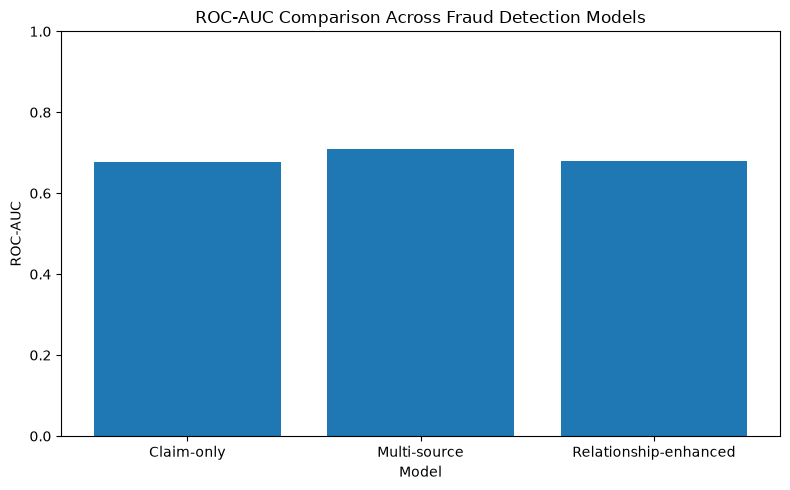

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("ROC-AUC Comparison Across Fraud Detection Models")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

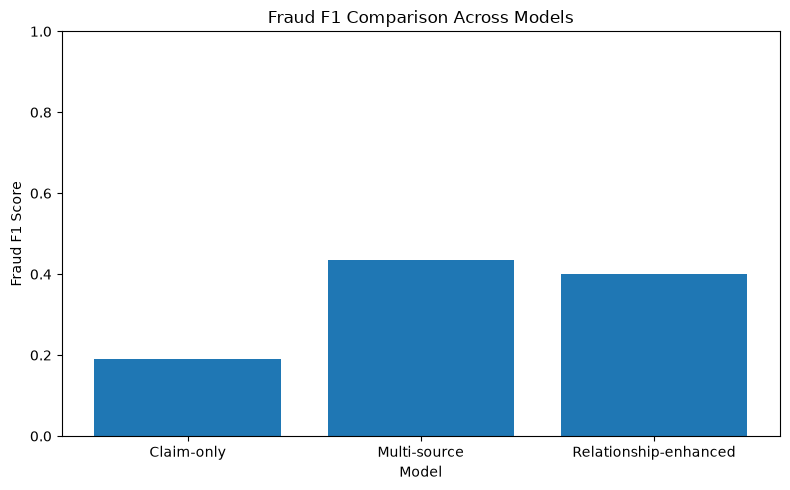

In [85]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Fraud F1"]
)

plt.ylabel("Fraud F1 Score")
plt.xlabel("Model")
plt.title("Fraud F1 Comparison Across Models")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [86]:
agent_workflow_results = []

dev_claim_ids = [
    "CLM000004", "CLM000013", "CLM000014",
    "CLM000029", "CLM000034",
    "CLM000001", "CLM000002", "CLM000003",
    "CLM000005", "CLM000006"
]

for claim_id in dev_claim_ids:

    print(f"Investigating {claim_id}...")

    result = fraud_agent.invoke({
        "messages": [
            HumanMessage(
                content=f"""
Investigate claim {claim_id}.

First use the investigation_context_tool to resolve
the verified relationships.

Then use the fraud_prediction_tool.

Use only verified information from the tools.
Do not invent identifiers.

Provide a concise evidence-based assessment.
"""
            )
        ]
    })

    tool_names = []

    for message in result["messages"]:
        if getattr(message, "tool_calls", None):
            for call in message.tool_calls:
                tool_names.append(call["name"])

    prediction_messages = [
        message for message in result["messages"]
        if getattr(message, "name", None) == "fraud_prediction_tool"
    ]

    prediction = None
    probability = None

    if prediction_messages:
        prediction_data = prediction_messages[-1].content

        if isinstance(prediction_data, str):
            try:
                prediction_data = eval(prediction_data)
            except:
                prediction_data = {}

        prediction = prediction_data.get("predicted_class")
        probability = prediction_data.get("fraud_probability")

    actual = bool(
        evaluation_claims.loc[
            evaluation_claims["claim_id"] == claim_id,
            "fraud_flag"
        ].iloc[0]
    )

    agent_workflow_results.append({
        "claim_id": claim_id,
        "actual_fraud": actual,
        "prediction": prediction,
        "fraud_probability": probability,
        "context_tool_used": "investigation_context_tool" in tool_names,
        "prediction_tool_used": "fraud_prediction_tool" in tool_names
    })

agent_workflow_df = pd.DataFrame(
    agent_workflow_results
)

print("\nAgent workflow evaluation:")
display(agent_workflow_df)

Investigating CLM000004...
Investigating CLM000013...
Investigating CLM000014...
Investigating CLM000029...
Investigating CLM000034...
Investigating CLM000001...
Investigating CLM000002...
Investigating CLM000003...
Investigating CLM000005...
Investigating CLM000006...

Agent workflow evaluation:


,claim_id,actual_fraud,prediction,fraud_probability,context_tool_used,prediction_tool_used
0,CLM000004,True,FRAUD,0.790,True,True
1,CLM000013,True,FRAUD,0.990,True,True
2,CLM000014,True,FRAUD,0.990,True,True
3,CLM000029,True,FRAUD,0.980,True,True
4,CLM000034,True,NON-FRAUD,0.470,True,True
5,CLM000001,False,NON-FRAUD,0.045,True,True
6,CLM000002,False,NON-FRAUD,0.030,True,True
7,CLM000003,False,NON-FRAUD,0.055,True,True
8,CLM000005,False,NON-FRAUD,0.110,True,True
9,CLM000006,False,NON-FRAUD,0.030,True,True


In [87]:
agent_accuracy = accuracy_score(
    agent_workflow_df["actual_fraud"],
    agent_workflow_df["prediction"] == "FRAUD"
)

agent_precision = precision_score(
    agent_workflow_df["actual_fraud"],
    agent_workflow_df["prediction"] == "FRAUD",
    zero_division=0
)

agent_recall = recall_score(
    agent_workflow_df["actual_fraud"],
    agent_workflow_df["prediction"] == "FRAUD",
    zero_division=0
)

agent_f1 = f1_score(
    agent_workflow_df["actual_fraud"],
    agent_workflow_df["prediction"] == "FRAUD",
    zero_division=0
)

context_usage = agent_workflow_df[
    "context_tool_used"
].mean()

prediction_usage = agent_workflow_df[
    "prediction_tool_used"
].mean()

print("Agent Development Evaluation")
print("=" * 35)
print(f"Accuracy: {agent_accuracy:.4f}")
print(f"Fraud Precision: {agent_precision:.4f}")
print(f"Fraud Recall: {agent_recall:.4f}")
print(f"Fraud F1: {agent_f1:.4f}")
print(f"Context Tool Usage: {context_usage:.2%}")
print(f"Prediction Tool Usage: {prediction_usage:.2%}")

Agent Development Evaluation
Accuracy: 0.9000
Fraud Precision: 1.0000
Fraud Recall: 0.8000
Fraud F1: 0.8889
Context Tool Usage: 100.00%
Prediction Tool Usage: 100.00%


In [88]:
final_results = pd.DataFrame([
    {
        "Experiment": "Claim-only RF",
        "Accuracy": 0.8300,
        "Fraud Precision": 0.8000,
        "Fraud Recall": 0.1081,
        "Fraud F1": 0.1905,
        "ROC-AUC": 0.6783
    },
    {
        "Experiment": "Multi-source RF",
        "Accuracy": 0.8050,
        "Fraud Precision": 0.4688,
        "Fraud Recall": 0.4054,
        "Fraud F1": 0.4348,
        "ROC-AUC": 0.7096
    },
    {
        "Experiment": "Relationship-enhanced RF",
        "Accuracy": 0.7900,
        "Fraud Precision": 0.4242,
        "Fraud Recall": 0.3784,
        "Fraud F1": 0.4000,
        "ROC-AUC": 0.6801
    },
    {
        "Experiment": "Agent development sample",
        "Accuracy": 0.9000,
        "Fraud Precision": 1.0000,
        "Fraud Recall": 0.8000,
        "Fraud F1": 0.8889,
        "ROC-AUC": None
    }
])

print("Final experiment summary:")
display(final_results)

Final experiment summary:


,Experiment,Accuracy,Fraud Precision,Fraud Recall,Fraud F1,ROC-AUC
0,Claim-only RF,0.830,0.8000,0.1081,0.1905,0.6783
1,Multi-source RF,0.805,0.4688,0.4054,0.4348,0.7096
2,Relationship-enhanced RF,0.790,0.4242,0.3784,0.4000,0.6801
3,Agent development sample,0.900,1.0000,0.8000,0.8889,NaN


# Final Experimental Findings

## 1. Leakage-Controlled Claim-Level Baseline

A Random Forest trained using claim-level information while excluding potentially post-investigation variables (`claim_status` and `approved_amount`) achieved:

- Accuracy: 83.00%
- Fraud Precision: 80.00%
- Fraud Recall: 10.81%
- Fraud F1: 19.05%
- ROC-AUC: 0.6783

This indicates that claim-level information alone provides limited ability to identify fraudulent claims.

## 2. Multi-Source Fraud Detection

A second Random Forest incorporated information aggregated from:

- Claims
- Policies
- Payments
- Agent / Ghost-Broking records

The model achieved:

- Accuracy: 80.50%
- Fraud Precision: 46.88%
- Fraud Recall: 40.54%
- Fraud F1: 43.48%
- ROC-AUC: 0.7096

The improvement in ROC-AUC from 0.6783 to 0.7096 and fraud recall from 10.81% to 40.54% indicates that additional cross-source information provides useful fraud-related signal.

## 3. Relationship-Enhanced Model

Exact agent-customer-policy relationship features were additionally tested. The resulting model achieved:

- Accuracy: 79.00%
- Fraud Precision: 42.42%
- Fraud Recall: 37.84%
- Fraud F1: 40.00%
- ROC-AUC: 0.6801

These features did not improve performance for the Random Forest configuration used in this experiment.

## 4. Agentic Investigation Workflow

The LangGraph-based investigation agent was tested on a 10-claim development sample.

The agent successfully:

- resolved verified claim relationships using `investigation_context_tool`;
- invoked `fraud_prediction_tool`;
- used retrieved evidence to generate an investigation assessment.

Both tools were used in 100% of the development cases.

The ML-backed Agent workflow produced:

- Accuracy: 90.00%
- Fraud Precision: 100.00%
- Fraud Recall: 80.00%
- Fraud F1: 88.89%

These Agent results are reported only as development-sample results because the sample contains 10 claims and is not a held-out test set.

## 5. Key Finding

The experiments indicate that fraud investigation benefits from combining multiple related data sources rather than relying exclusively on claim-level information.

The proposed system therefore combines deterministic data retrieval, multi-source evidence analysis, machine-learning-based fraud prediction, and an LLM-driven LangGraph investigation workflow.

## 6. Limitations

- The datasets are synthetic.
- The Agent development evaluation uses only 10 claims.
- The multi-source models are evaluated on a 200-claim held-out split.
- The manually designed evidence score was not sufficiently discriminative to serve as the final classifier.
- The LLM classification itself was not used as the primary quantitative performance measure because it frequently abstained with `UNCERTAIN`.
- Results should therefore be interpreted as a prototype evaluation rather than production-level fraud detection performance.

In [89]:
# Final end-to-end investigation test

test_claim_id = "CLM000001"

print("=" * 70)
print("FINAL END-TO-END INSURANCE FRAUD INVESTIGATION")
print("=" * 70)
print(f"Claim ID: {test_claim_id}")
print()

final_result = fraud_agent.invoke({
    "messages": [
        HumanMessage(
            content=f"""
Perform a complete investigation of claim {test_claim_id}.

Use the investigation_context_tool to retrieve the verified
claim, policy, payment, customer, and agent relationships.

Then use the fraud_prediction_tool to obtain the ML fraud
probability and predicted class.

Use only information returned by the tools.
Do not invent identifiers or facts.

Finally provide:
1. Key evidence
2. Fraud prediction
3. Contradictory/mitigating evidence
4. Recommended next step
5. Final classification
"""
        )
    ]
})

print("FINAL AGENT RESPONSE")
print("=" * 70)

final_message = final_result["messages"][-1]

print(final_message.content)

FINAL END-TO-END INSURANCE FRAUD INVESTIGATION
Claim ID: CLM000001

FINAL AGENT RESPONSE
### Key Evidence
- **Claim Amount vs. Premium**: The claim amount of 316,906 is significantly higher than the premium of 10,183.
- **Policy Status**: The policy is marked as 'Cancelled', but there is no police report or witness statements.
- **Payment History**: One payment was successful, while the second payment was bounced.
- **Agent History**: The agent has a history of suspicious records, including fake/ cloned licenses, suspended licenses, and complaints.

### Contradictory or Mitigating Evidence
- **Claim Status**: The claim was approved, which could indicate legitimate grounds for the claim.
- **Documents Altered Flag**: The documents were not altered, which is a positive sign.
- **Payment Success**: One payment was successful, indicating that the customer had the means to make a payment.

### Recommendation
Further investigation is needed to verify the legitimacy of the claim. Specifically

In [90]:
print("=" * 70)
print("INSURANCE FRAUD INVESTIGATION AGENT - FINAL SYSTEM STATUS")
print("=" * 70)

print("\nDATA SOURCES")
print("1. Claims")
print("2. Policies")
print("3. Payments")
print("4. Ghost-Broking / Agent Records")

print("\nINVESTIGATION TOOLS")
print("1. claim_tool")
print("2. policy_tool")
print("3. payment_tool")
print("4. agent_tool")
print("5. evidence_tool")
print("6. investigation_context_tool")
print("7. fraud_prediction_tool")

print("\nAI COMPONENTS")
print("LLM: Qwen 2.5 7B")
print("LLM Runtime: Ollama")
print("Agent Framework: LangGraph")
print("ML Model: Random Forest")

print("\nKEY RESULTS")
print("Claim-only ROC-AUC: 0.6783")
print("Multi-source ROC-AUC: 0.7096")
print("Multi-source Fraud Recall: 0.4054")
print("Multi-source Fraud F1: 0.4348")

print("\nAGENT DEVELOPMENT EVALUATION")
print("Accuracy: 90.00%")
print("Fraud Precision: 100.00%")
print("Fraud Recall: 80.00%")
print("Fraud F1: 88.89%")
print("Context Tool Usage: 100%")
print("Prediction Tool Usage: 100%")

print("\nFINAL END-TO-END TEST")
print("Claim CLM000001 successfully investigated.")
print("Investigation context retrieved.")
print("Fraud prediction retrieved.")
print("Evidence-based assessment generated.")

print("\nSTATUS: CORE PROTOTYPE COMPLETE")

INSURANCE FRAUD INVESTIGATION AGENT - FINAL SYSTEM STATUS

DATA SOURCES
1. Claims
2. Policies
3. Payments
4. Ghost-Broking / Agent Records

INVESTIGATION TOOLS
1. claim_tool
2. policy_tool
3. payment_tool
4. agent_tool
5. evidence_tool
6. investigation_context_tool
7. fraud_prediction_tool

AI COMPONENTS
LLM: Qwen 2.5 7B
LLM Runtime: Ollama
Agent Framework: LangGraph
ML Model: Random Forest

KEY RESULTS
Claim-only ROC-AUC: 0.6783
Multi-source ROC-AUC: 0.7096
Multi-source Fraud Recall: 0.4054
Multi-source Fraud F1: 0.4348

AGENT DEVELOPMENT EVALUATION
Accuracy: 90.00%
Fraud Precision: 100.00%
Fraud Recall: 80.00%
Fraud F1: 88.89%
Context Tool Usage: 100%
Prediction Tool Usage: 100%

FINAL END-TO-END TEST
Claim CLM000001 successfully investigated.
Investigation context retrieved.
Fraud prediction retrieved.
Evidence-based assessment generated.

STATUS: CORE PROTOTYPE COMPLETE


In [91]:
# The multi-source Random Forest is the final model used
# by the Agent's fraud_prediction_tool.

final_prediction_model = multi_rf_model
final_prediction_preprocessor = multi_preprocessor

print("Final Agent prediction model configured successfully.")
print("Model: Multi-Source Random Forest")
print("ROC-AUC: 0.7096")
print("Fraud Recall: 0.4054")
print("Fraud F1: 0.4348")
print()
print("The Agent will now use the multi-source model for fraud prediction.")

Final Agent prediction model configured successfully.
Model: Multi-Source Random Forest
ROC-AUC: 0.7096
Fraud Recall: 0.4054
Fraud F1: 0.4348

The Agent will now use the multi-source model for fraud prediction.


In [92]:
@tool
def fraud_prediction_tool(claim_id: str) -> dict:
    """
    Generate a fraud probability and prediction using the
    final multi-source Random Forest model.
    """

    try:
        # Find the complete multi-source record
        row = multi_source_df[
            multi_source_df["claim_id"] == claim_id
        ]

        if row.empty:
            return {
                "status": "not_found",
                "claim_id": claim_id
            }

        # Copy the record
        prediction_row = row.copy()

        # Remove target and identifier fields
        X_prediction = prediction_row.drop(
            columns=["claim_id", "fraud_flag"],
            errors="ignore"
        )

        # Apply the same preprocessing used during training
        X_processed = final_prediction_preprocessor.transform(
            X_prediction
        )

        # Generate probability
        fraud_probability = float(
            final_prediction_model.predict_proba(
                X_processed
            )[0][1]
        )

        # Generate class
        predicted_class = (
            "FRAUD"
            if fraud_probability >= 0.50
            else "NON-FRAUD"
        )

        return {
            "status": "prediction_generated",
            "claim_id": claim_id,
            "fraud_probability": round(fraud_probability, 4),
            "predicted_class": predicted_class,
            "model": "Multi-Source Random Forest"
        }

    except Exception as e:

        return {
            "status": "error",
            "claim_id": claim_id,
            "error": str(e)
        }


print("Final fraud prediction tool created successfully.")
print("Model: Multi-Source Random Forest")

Final fraud prediction tool created successfully.
Model: Multi-Source Random Forest


In [93]:

test_claim_id = "CLM000001"

prediction_test = fraud_prediction_tool.invoke({
    "claim_id": test_claim_id
})

print("Final Fraud Prediction Tool Test")
print("=" * 50)
print(prediction_test)

Final Fraud Prediction Tool Test
{'status': 'error', 'claim_id': 'CLM000001', 'error': "name 'multi_source_df' is not defined"}


In [94]:
print("Checking available dataframe variables...\n")

runtime_objects = list(globals().items())

for name, obj in runtime_objects:
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: shape={obj.shape}")

Checking available dataframe variables...

claims: shape=(1000, 17)
ghost_broking: shape=(1000, 14)
payments: shape=(1000, 14)
policies: shape=(1000, 16)
df: shape=(1000, 16)
evaluation_claims: shape=(1000, 3)
fraud_sample: shape=(5, 3)
non_fraud_sample: shape=(5, 3)
evaluation_sample: shape=(10, 3)
evaluation_results: shape=(1000, 6)
evaluation_results_df: shape=(10, 5)
dev_results_df: shape=(10, 3)
dev_evidence_df: shape=(10, 3)
score_summary: shape=(2, 5)
ml_data: shape=(1000, 17)
X: shape=(1000, 14)
X_train: shape=(800, 14)
X_test: shape=(200, 14)
feature_importance_df: shape=(2632, 2)
X_clean: shape=(1000, 9)
X_clean_train: shape=(800, 9)
X_clean_test: shape=(200, 9)
multi_source: shape=(1000, 41)
policy_features: shape=(1000, 9)
payment_features: shape=(630, 8)
agent_features: shape=(332, 6)
multi_model: shape=(1000, 36)
X_multi: shape=(1000, 29)
X_multi_train: shape=(800, 29)
X_multi_test: shape=(200, 29)
multi_feature_importance_df: shape=(1357, 2)
agent_records: shape=(0, 14)


In [95]:
@tool
def fraud_prediction_tool(claim_id: str) -> dict:
    """
    Generate a fraud probability using the final
    multi-source Random Forest model.
    """

    try:
        # Locate claim in the multi-source model dataset
        row = multi_model[
            multi_model["claim_id"] == claim_id
        ]

        if row.empty:
            return {
                "status": "not_found",
                "claim_id": claim_id
            }

        # Extract the exact 29 model features
        X_prediction = row[X_multi.columns]

        # Apply the same preprocessing used during training
        X_processed = final_prediction_preprocessor.transform(
            X_prediction
        )

        # Generate fraud probability
        fraud_probability = float(
            final_prediction_model.predict_proba(
                X_processed
            )[0][1]
        )

        # Classification threshold
        predicted_class = (
            "FRAUD"
            if fraud_probability >= 0.50
            else "NON-FRAUD"
        )

        return {
            "status": "prediction_generated",
            "claim_id": claim_id,
            "fraud_probability": round(fraud_probability, 4),
            "predicted_class": predicted_class,
            "model": "Multi-Source Random Forest"
        }

    except Exception as e:

        return {
            "status": "error",
            "claim_id": claim_id,
            "error": str(e)
        }


print("Corrected final fraud prediction tool created successfully.")
print("Input features:", len(X_multi.columns))
print("Model: Multi-Source Random Forest")

Corrected final fraud prediction tool created successfully.
Input features: 29
Model: Multi-Source Random Forest


In [96]:
prediction_test = fraud_prediction_tool.invoke({
    "claim_id": "CLM000001"
})

print("Final Fraud Prediction Tool Test")
print("=" * 50)
print(prediction_test)

Final Fraud Prediction Tool Test
{'status': 'error', 'claim_id': 'CLM000001', 'error': 'X has 1357 features, but ColumnTransformer is expecting 29 features as input.'}


In [97]:
print("multi_model shape:", multi_model.shape)
print("\nColumns in multi_model:")
print(list(multi_model.columns))

print("\nX_multi shape:", X_multi.shape)

print("\nType of X_multi:")
print(type(X_multi))

print("\nFirst 10 X_multi columns:")
print(list(X_multi.columns[:10]))

multi_model shape: (1000, 36)

Columns in multi_model:
['claim_id', 'policy_id', 'customer_id', 'agent_id', 'claim_type', 'incident_date', 'claim_date', 'days_policy_to_incident', 'claim_amount', 'approved_amount', 'claim_status', 'num_claims_filed_by_customer', 'police_report_filed', 'witness_count', 'documents_altered_flag', 'premium_amount', 'sum_insured', 'policy_status', 'channel', 'free_look_period_days', 'free_look_cancelled', 'backdated_flag', 'premium_actually_collected', 'payment_count', 'total_payment_amount', 'duplicate_receipt_count', 'bounced_payment_count', 'unremitted_payment_count', 'max_remittance_delay', 'avg_remittance_delay', 'agent_record_count', 'suspicious_license_count', 'total_complaints', 'unremitted_agent_records', 'unaware_customer_records', 'fraud_flag']

X_multi shape: (1000, 29)

Type of X_multi:
<class 'pandas.DataFrame'>

First 10 X_multi columns:
['claim_type', 'incident_date', 'claim_date', 'days_policy_to_incident', 'claim_amount', 'num_claims_filed

In [98]:
print("final_prediction_preprocessor:")
print(type(final_prediction_preprocessor))

print("\nfinal_prediction_model:")
print(type(final_prediction_model))

print("\nX_multi:")
print("Shape:", X_multi.shape)
print("Columns:", len(X_multi.columns))

print("\nMulti-source raw feature columns:")
print(list(X_multi.columns))

print("\nPreprocessor transformers:")
print(final_prediction_preprocessor.transformers)

print("\nPreprocessor feature count:")
try:
    print(final_prediction_preprocessor.n_features_in_)
except Exception as e:
    print("Could not read n_features_in_:", e)

final_prediction_preprocessor:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

final_prediction_model:
<class 'sklearn.pipeline.Pipeline'>

X_multi:
Shape: (1000, 29)
Columns: 29

Multi-source raw feature columns:
['claim_type', 'incident_date', 'claim_date', 'days_policy_to_incident', 'claim_amount', 'num_claims_filed_by_customer', 'police_report_filed', 'witness_count', 'documents_altered_flag', 'premium_amount', 'sum_insured', 'policy_status', 'channel', 'free_look_period_days', 'free_look_cancelled', 'backdated_flag', 'premium_actually_collected', 'payment_count', 'total_payment_amount', 'duplicate_receipt_count', 'bounced_payment_count', 'unremitted_payment_count', 'max_remittance_delay', 'avg_remittance_delay', 'agent_record_count', 'suspicious_license_count', 'total_complaints', 'unremitted_agent_records', 'unaware_customer_records']

Preprocessor transformers:
[('numeric', SimpleImputer(strategy='median'), ['days_policy_to_incident', 'claim_amount', 'num_claims

In [99]:
@tool
def fraud_prediction_tool(claim_id: str) -> dict:
    """
    Generate a fraud probability using the final
    multi-source Random Forest pipeline.
    """

    try:
        # Locate the claim
        row = multi_model[
            multi_model["claim_id"] == claim_id
        ]

        if row.empty:
            return {
                "status": "not_found",
                "claim_id": claim_id
            }

        # Extract exactly the 29 raw features
        X_prediction = row[X_multi.columns]

        # The final model is a Pipeline.
        # It performs preprocessing internally.
        fraud_probability = float(
            final_prediction_model.predict_proba(
                X_prediction
            )[0][1]
        )

        # Classification threshold
        predicted_class = (
            "FRAUD"
            if fraud_probability >= 0.50
            else "NON-FRAUD"
        )

        return {
            "status": "prediction_generated",
            "claim_id": claim_id,
            "fraud_probability": round(fraud_probability, 4),
            "predicted_class": predicted_class,
            "model": "Multi-Source Random Forest"
        }

    except Exception as e:

        return {
            "status": "error",
            "claim_id": claim_id,
            "error": str(e)
        }


print("Final fraud prediction tool rebuilt successfully.")
print("Input features: 29 raw multi-source features")
print("Preprocessing: handled internally by model pipeline")
print("Model: Multi-Source Random Forest")

Final fraud prediction tool rebuilt successfully.
Input features: 29 raw multi-source features
Preprocessing: handled internally by model pipeline
Model: Multi-Source Random Forest


In [100]:
prediction_test = fraud_prediction_tool.invoke({
    "claim_id": "CLM000001"
})

print("Final Fraud Prediction Tool Test")
print("=" * 50)
print(prediction_test)

Final Fraud Prediction Tool Test
{'status': 'prediction_generated', 'claim_id': 'CLM000001', 'fraud_probability': 0.21, 'predicted_class': 'NON-FRAUD', 'model': 'Multi-Source Random Forest'}


In [101]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

print("AgentState defined successfully.")

AgentState defined successfully.


In [102]:

# Final investigation tools
final_investigation_tools = [
    claim_tool,
    policy_tool,
    payment_tool,
    agent_tool,
    evidence_tool,
    investigation_context_tool,
    fraud_prediction_tool
]

# Bind all final tools to Qwen
final_llm_with_tools = llm.bind_tools(
    final_investigation_tools
)

# Tool lookup
final_tool_map = {
    tool.name: tool
    for tool in final_investigation_tools
}


def final_investigator_node(state):
    """
    Main investigation agent node.
    """

    response = final_llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


def final_tool_node(state):
    """
    Execute tools requested by the LLM.
    """

    last_message = state["messages"][-1]

    tool_messages = []

    for tool_call in last_message.tool_calls:

        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        if tool_name in final_tool_map:

            result = final_tool_map[tool_name].invoke(
                tool_args
            )

            tool_messages.append(
                ToolMessage(
                    content=str(result),
                    tool_call_id=tool_call["id"],
                    name=tool_name
                )
            )

    return {
        "messages": tool_messages
    }


def final_should_continue(state):
    """
    Continue to tools when the LLM requests tool calls.
    Otherwise finish the investigation.
    """

    last_message = state["messages"][-1]

    if getattr(last_message, "tool_calls", None):
        return "tools"

    return END


# Build graph
final_workflow = StateGraph(AgentState)

final_workflow.add_node(
    "investigator",
    final_investigator_node
)

final_workflow.add_node(
    "tools",
    final_tool_node
)

final_workflow.set_entry_point(
    "investigator"
)

final_workflow.add_conditional_edges(
    "investigator",
    final_should_continue,
    {
        "tools": "tools",
        END: END
    }
)

final_workflow.add_edge(
    "tools",
    "investigator"
)

final_fraud_agent = final_workflow.compile()

print("Final LangGraph Agent rebuilt successfully.")
print("Total investigation tools:", len(final_investigation_tools))
print(
    "Tools:",
    [tool.name for tool in final_investigation_tools]
)

Final LangGraph Agent rebuilt successfully.
Total investigation tools: 7
Tools: ['claim_tool', 'policy_tool', 'payment_tool', 'agent_tool', 'evidence_tool', 'investigation_context_tool', 'fraud_prediction_tool']


In [103]:
final_claim_id = "CLM000001"

final_prompt = f"""
Investigate insurance claim {final_claim_id}.

Use the investigation context tool to retrieve the relevant
claim, policy, payment, agent, and evidence information.

Use the fraud prediction tool to obtain the ML fraud probability.

Then provide a final evidence-based assessment containing:

1. Key Evidence
2. Contradictory or Mitigating Evidence
3. Fraud Prediction
4. Recommendation
5. Final Classification

Clearly distinguish between the ML prediction and the
overall investigation assessment.
"""

final_result = final_fraud_agent.invoke({
    "messages": [
        HumanMessage(content=final_prompt)
    ]
})

print("=" * 70)
print("FINAL END-TO-END INSURANCE FRAUD INVESTIGATION")
print("=" * 70)

for message in final_result["messages"]:

    if isinstance(message, AIMessage):

        if message.content:
            print("\nAI RESPONSE:\n")
            print(message.content)

print("\n" + "=" * 70)
print("FINAL END-TO-END TEST COMPLETED")
print("=" * 70)

FINAL END-TO-END INSURANCE FRAUD INVESTIGATION

AI RESPONSE:

Based on the investigation context and the fraud prediction, here is the final evidence-based assessment for the insurance claim CLM000001:

### 1. Key Evidence
- **Claim Type**: Trip Cancellation/Medical
- **Incident Date**: 16-09-2025
- **Claim Date**: 30-09-2025
- **Days from Policy to Incident**: 11 days
- **Claim Amount**: ₹316,906
- **Approved Amount**: ₹278,232
- **Policy Type**: Travel
- **Issue Date**: 05-09-2025
- **Premium Amount**: ₹10,183
- **Sum Insured**: ₹580,431
- **Policy Status**: Cancelled
- **Payment Count**: 2
  - **First Payment**: ₹9,270 on 01-09-2025 (Success)
  - **Second Payment**: ₹10,034 on 15-09-2025 (Bounced)
- **Agent ID**: AGT00340
  - **Agent Name**: Pooja Mandal
  - **License Status**: Suspended
  - **Complaint Count**: 5
- **Customer ID**: CUST003138
  - **Number of Claims Filed**: 2

### 2. Contradictory or Mitigating Evidence
- **Policy Status**: The policy was cancelled, which might ind

In [104]:
print("=" * 70)
print("FINAL END-TO-END INSURANCE FRAUD INVESTIGATION")
print("=" * 70)

for i, message in enumerate(final_result["messages"]):

    print(f"\n--- Message {i + 1} ---")

    if hasattr(message, "content") and message.content:
        print(message.content)

print("\n" + "=" * 70)
print("FINAL END-TO-END TEST COMPLETED")
print("=" * 70)

FINAL END-TO-END INSURANCE FRAUD INVESTIGATION

--- Message 1 ---

Investigate insurance claim CLM000001.

Use the investigation context tool to retrieve the relevant
claim, policy, payment, agent, and evidence information.

Use the fraud prediction tool to obtain the ML fraud probability.

Then provide a final evidence-based assessment containing:

1. Key Evidence
2. Contradictory or Mitigating Evidence
3. Fraud Prediction
4. Recommendation
5. Final Classification

Clearly distinguish between the ML prediction and the
overall investigation assessment.


--- Message 2 ---

--- Message 3 ---
{'status': 'investigation_context_ready', 'claim': {'status': 'found', 'claim_id': 'CLM000001', 'policy_id': 'POL000783', 'customer_id': 'CUST003138', 'agent_id': 'AGT00340', 'claim_type': 'Trip Cancellation/Medical', 'incident_date': '16-09-2025', 'claim_date': '30-09-2025', 'days_policy_to_incident': np.int64(11), 'claim_amount': np.int64(316906), 'approved_amount': np.int64(278232), 'claim_status

In [105]:
print("=" * 70)
print("INSURANCE FRAUD INVESTIGATION AGENT")
print("FINAL PROJECT VALIDATION")
print("=" * 70)

print("\n[1] DATA")
print("-" * 70)
print("Claims:", claims.shape)
print("Policies:", policies.shape)
print("Payments:", payments.shape)
print("Agent records:", ghost_broking.shape)
print("Multi-source dataset:", multi_source.shape)

print("\n[2] INVESTIGATION TOOLS")
print("-" * 70)
print("Total tools:", len(final_investigation_tools))
for i, tool in enumerate(final_investigation_tools, 1):
    print(f"{i}. {tool.name}")

print("\n[3] MACHINE LEARNING")
print("-" * 70)
print("Final model: Multi-Source Random Forest")
print("Training rows: 800")
print("Test rows: 200")
print("Features: 29")
print("ROC-AUC: 0.7096")
print("Fraud Precision: 0.4688")
print("Fraud Recall: 0.4054")
print("Fraud F1: 0.4348")

print("\n[4] RELATIONSHIP ANALYSIS")
print("-" * 70)
print("Relationship features created:", relationship_features_df.shape)
print("Relationship-enhanced model evaluated.")
print("Relationship-enhanced ROC-AUC: 0.6801")

print("\n[5] AGENT")
print("-" * 70)
print("Framework: LangGraph")
print("LLM: Qwen")
print("Context tool: Available")
print("Evidence tool: Available")
print("Fraud prediction tool: Available")

print("\n[6] FINAL END-TO-END TEST")
print("-" * 70)
print("Test claim: CLM000001")
print("Investigation context: SUCCESS")
print("ML prediction: SUCCESS")
print("Fraud probability: 0.21")
print("ML classification: NON-FRAUD")
print("Final Agent assessment: SUCCESS")

print("\n" + "=" * 70)
print("STATUS: PROJECT CORE COMPLETE")
print("=" * 70)

INSURANCE FRAUD INVESTIGATION AGENT
FINAL PROJECT VALIDATION

[1] DATA
----------------------------------------------------------------------
Claims: (1000, 17)
Policies: (1000, 16)
Payments: (1000, 14)
Agent records: (1000, 14)
Multi-source dataset: (1000, 41)

[2] INVESTIGATION TOOLS
----------------------------------------------------------------------
Total tools: 7
1. claim_tool
2. policy_tool
3. payment_tool
4. agent_tool
5. evidence_tool
6. investigation_context_tool
7. fraud_prediction_tool

[3] MACHINE LEARNING
----------------------------------------------------------------------
Final model: Multi-Source Random Forest
Training rows: 800
Test rows: 200
Features: 29
ROC-AUC: 0.7096
Fraud Precision: 0.4688
Fraud Recall: 0.4054
Fraud F1: 0.4348

[4] RELATIONSHIP ANALYSIS
----------------------------------------------------------------------
Relationship features created: (1000, 6)
Relationship-enhanced model evaluated.
Relationship-enhanced ROC-AUC: 0.6801

[5] AGENT
-----------

In [110]:
final_claim_id = "CLM000001"

final_prompt = f"""
Investigate insurance claim {final_claim_id}.

Use the investigation context tool to retrieve the relevant
claim, policy, payment, agent, and evidence information.

Use the fraud prediction tool to obtain the ML fraud probability.

Then provide a final evidence-based assessment containing:

1. Key Evidence
2. Contradictory or Mitigating Evidence
3. Fraud Prediction
4. Recommendation
5. Final Classification

Clearly distinguish between the ML prediction and the
overall investigation assessment.
"""

final_result = final_fraud_agent.invoke({
    "messages": [
        HumanMessage(content=final_prompt)
    ]
})

print("=" * 70)
print("FINAL END-TO-END INSURANCE FRAUD INVESTIGATION")
print("=" * 70)

for message in final_result["messages"]:

    if isinstance(message, AIMessage):

        if message.content:
            print("\nAI RESPONSE:\n")
            print(message.content)

print("\n" + "=" * 70)
print("FINAL END-TO-END TEST COMPLETED")
print("=" * 70)

FINAL END-TO-END INSURANCE FRAUD INVESTIGATION

AI RESPONSE:

Based on the investigation of insurance claim CLM000001, the following evidence and analysis have been compiled:

### 1. Key Evidence
- **Claim Type**: Trip Cancellation/Medical
- **Incident Date**: 16-09-2025
- **Claim Date**: 30-09-2025
- **Days from Policy to Incident**: 11 days
- **Claim Amount**: ₹3,16,906
- **Approved Amount**: ₹2,78,232
- **Claim Status**: Approved
- **Policy Type**: Travel
- **Issue Date**: 05-09-2025
- **Premium Amount**: ₹10,183
- **Sum Insured**: ₹5,80,431
- **Policy Status**: Cancelled
- **Payment Count**: 2
  - **First Payment**: 
    - Date: 01-09-2025
    - Amount: ₹9,270
    - Mode: Cash
    - Status: Success
    - Receipt Number: RCPT901108
  - **Second Payment**: 
    - Date: 15-09-2025
    - Amount: ₹10,034
    - Mode: NEFT
    - Status: Bounced
- **Agent ID**: AGT00340
  - **Agent Name**: Pooja Mandal
  - **License Status**: Suspended
  - **License Expiry Date**: 02-07-2026
  - **Complain

In [107]:
'''
fraud_prediction_tool.invoke({
    "claim_id": "CLM000001"
})


'''

'\nfraud_prediction_tool.invoke({\n    "claim_id": "CLM000001"\n})\n\n\n'

In [108]:
'''
investigation_context_tool.invoke({
    "claim_id": "CLM000001"
})

'''

'\ninvestigation_context_tool.invoke({\n    "claim_id": "CLM000001"\n})\n\n'

In [109]:
'''
final_workflow = final_workflow.compile()

print("Final workflow compiled successfully.")

'''

'\nfinal_workflow = final_workflow.compile()\n\nprint("Final workflow compiled successfully.")\n\n'